# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

<h1>Оглавление<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Общая-информация-о-данных" data-toc-modified-id="Общая-информация-о-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Общая информация о данных</a></span><ul class="toc-item"><li><span><a href="#Первичный-анализ-данных" data-toc-modified-id="Первичный-анализ-данных-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Первичный анализ данных</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Работа-с-пропусками-и-дубликатами,-преобразование-типов-данных" data-toc-modified-id="Работа-с-пропусками-и-дубликатами,-преобразование-типов-данных-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Работа с пропусками и дубликатами, преобразование типов данных</a></span><ul class="toc-item"><li><span><a href="#Парки-и-пруды" data-toc-modified-id="Парки-и-пруды-3.1.1"><span class="toc-item-num">3.1.1&nbsp;&nbsp;</span>Парки и пруды</a></span></li><li><span><a href="#Балконы" data-toc-modified-id="Балконы-3.1.2"><span class="toc-item-num">3.1.2&nbsp;&nbsp;</span>Балконы</a></span></li><li><span><a href="#Количество-этажей-в-доме" data-toc-modified-id="Количество-этажей-в-доме-3.1.3"><span class="toc-item-num">3.1.3&nbsp;&nbsp;</span>Количество этажей в доме</a></span></li><li><span><a href="#Дата-выставления-объявления-на-продажу" data-toc-modified-id="Дата-выставления-объявления-на-продажу-3.1.4"><span class="toc-item-num">3.1.4&nbsp;&nbsp;</span>Дата выставления объявления на продажу</a></span></li><li><span><a href="#Количество-дней-размещения-объявления-до-снятия" data-toc-modified-id="Количество-дней-размещения-объявления-до-снятия-3.1.5"><span class="toc-item-num">3.1.5&nbsp;&nbsp;</span>Количество дней размещения объявления до снятия</a></span></li><li><span><a href="#Апартаменты" data-toc-modified-id="Апартаменты-3.1.6"><span class="toc-item-num">3.1.6&nbsp;&nbsp;</span>Апартаменты</a></span></li><li><span><a href="#Название-поселения" data-toc-modified-id="Название-поселения-3.1.7"><span class="toc-item-num">3.1.7&nbsp;&nbsp;</span>Название поселения</a></span></li><li><span><a href="#Работа-с-дубликатами-в-названии-поселений" data-toc-modified-id="Работа-с-дубликатами-в-названии-поселений-3.1.8"><span class="toc-item-num">3.1.8&nbsp;&nbsp;</span>Работа с дубликатами в названии поселений</a></span></li><li><span><a href="#Площаль-кухни-и-жилая-площадь" data-toc-modified-id="Площаль-кухни-и-жилая-площадь-3.1.9"><span class="toc-item-num">3.1.9&nbsp;&nbsp;</span>Площаль кухни и жилая площадь</a></span></li><li><span><a href="#Расстояния-до-центра-города-и-аэропорта" data-toc-modified-id="Расстояния-до-центра-города-и-аэропорта-3.1.10"><span class="toc-item-num">3.1.10&nbsp;&nbsp;</span>Расстояния до центра города и аэропорта</a></span></li><li><span><a href="#Высота-потолка" data-toc-modified-id="Высота-потолка-3.1.11"><span class="toc-item-num">3.1.11&nbsp;&nbsp;</span>Высота потолка</a></span></li></ul></li><li><span><a href="#Работа-с-явными-аномалиями" data-toc-modified-id="Работа-с-явными-аномалиями-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Работа с явными аномалиями</a></span><ul class="toc-item"><li><span><a href="#last_price" data-toc-modified-id="last_price-3.2.1"><span class="toc-item-num">3.2.1&nbsp;&nbsp;</span><code>last_price</code></a></span></li><li><span><a href="#total_area" data-toc-modified-id="total_area-3.2.2"><span class="toc-item-num">3.2.2&nbsp;&nbsp;</span><code>total_area</code></a></span></li><li><span><a href="#rooms" data-toc-modified-id="rooms-3.2.3"><span class="toc-item-num">3.2.3&nbsp;&nbsp;</span><code>rooms</code></a></span></li><li><span><a href="#ceiling_height" data-toc-modified-id="ceiling_height-3.2.4"><span class="toc-item-num">3.2.4&nbsp;&nbsp;</span><code>ceiling_height</code></a></span></li><li><span><a href="#floors_total-и-floors" data-toc-modified-id="floors_total-и-floors-3.2.5"><span class="toc-item-num">3.2.5&nbsp;&nbsp;</span><code>floors_total</code> и <code>floors</code></a></span></li><li><span><a href="#living_area" data-toc-modified-id="living_area-3.2.6"><span class="toc-item-num">3.2.6&nbsp;&nbsp;</span><code>living_area</code></a></span></li><li><span><a href="#kitchen_area" data-toc-modified-id="kitchen_area-3.2.7"><span class="toc-item-num">3.2.7&nbsp;&nbsp;</span><code>kitchen_area</code></a></span></li><li><span><a href="#balcony" data-toc-modified-id="balcony-3.2.8"><span class="toc-item-num">3.2.8&nbsp;&nbsp;</span><code>balcony</code></a></span></li><li><span><a href="#Выбросываем-указанные-аномалии" data-toc-modified-id="Выбросываем-указанные-аномалии-3.2.9"><span class="toc-item-num">3.2.9&nbsp;&nbsp;</span>Выбросываем указанные аномалии</a></span></li></ul></li><li><span><a href="#Вспомогательные-столбцы-для-удобства-анализа" data-toc-modified-id="Вспомогательные-столбцы-для-удобства-анализа-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Вспомогательные столбцы для удобства анализа</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Проведите-исследовательский-анализ-данных" data-toc-modified-id="Проведите-исследовательский-анализ-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Проведите исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Описание-параметров" data-toc-modified-id="Описание-параметров-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Описание параметров</a></span><ul class="toc-item"><li><span><a href="#Общая-площадь-кваритры" data-toc-modified-id="Общая-площадь-кваритры-4.1.1"><span class="toc-item-num">4.1.1&nbsp;&nbsp;</span>Общая площадь кваритры</a></span></li><li><span><a href="#Жилая-площадь" data-toc-modified-id="Жилая-площадь-4.1.2"><span class="toc-item-num">4.1.2&nbsp;&nbsp;</span>Жилая площадь</a></span></li><li><span><a href="#Площадь-кухни" data-toc-modified-id="Площадь-кухни-4.1.3"><span class="toc-item-num">4.1.3&nbsp;&nbsp;</span>Площадь кухни</a></span></li><li><span><a href="#Цена-объекта" data-toc-modified-id="Цена-объекта-4.1.4"><span class="toc-item-num">4.1.4&nbsp;&nbsp;</span>Цена объекта</a></span></li><li><span><a href="#Количество-комнат" data-toc-modified-id="Количество-комнат-4.1.5"><span class="toc-item-num">4.1.5&nbsp;&nbsp;</span>Количество комнат</a></span></li><li><span><a href="#Высота-потолков" data-toc-modified-id="Высота-потолков-4.1.6"><span class="toc-item-num">4.1.6&nbsp;&nbsp;</span>Высота потолков</a></span></li><li><span><a href="#Тип-этажа-квартиры" data-toc-modified-id="Тип-этажа-квартиры-4.1.7"><span class="toc-item-num">4.1.7&nbsp;&nbsp;</span>Тип этажа квартиры</a></span></li><li><span><a href="#Общее-количество-этажей-в-доме" data-toc-modified-id="Общее-количество-этажей-в-доме-4.1.8"><span class="toc-item-num">4.1.8&nbsp;&nbsp;</span>Общее количество этажей в доме</a></span></li><li><span><a href="#Расстояние-до-центра-города-в-метрах" data-toc-modified-id="Расстояние-до-центра-города-в-метрах-4.1.9"><span class="toc-item-num">4.1.9&nbsp;&nbsp;</span>Расстояние до центра города в метрах</a></span></li><li><span><a href="#Расстояние-до-ближайшего-парка" data-toc-modified-id="Расстояние-до-ближайшего-парка-4.1.10"><span class="toc-item-num">4.1.10&nbsp;&nbsp;</span>Расстояние до ближайшего парка</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.1.11"><span class="toc-item-num">4.1.11&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Скорость-продажи-квартиры" data-toc-modified-id="Скорость-продажи-квартиры-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Скорость продажи квартиры</a></span><ul class="toc-item"><li><span><a href="#Построим-диаграммы-распределения-по-длительности-публикации" data-toc-modified-id="Построим-диаграммы-распределения-по-длительности-публикации-4.2.1"><span class="toc-item-num">4.2.1&nbsp;&nbsp;</span>Построим диаграммы распределения по длительности публикации</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.2.2"><span class="toc-item-num">4.2.2&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Определение-факторов,-больше-всего-влияющих-на-общую-(полную)-стоимость-объекта" data-toc-modified-id="Определение-факторов,-больше-всего-влияющих-на-общую-(полную)-стоимость-объекта-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Определение факторов, больше всего влияющих на общую (полную) стоимость объекта</a></span><ul class="toc-item"><li><span><a href="#Стоимость-объектов" data-toc-modified-id="Стоимость-объектов-4.3.1"><span class="toc-item-num">4.3.1&nbsp;&nbsp;</span>Стоимость объектов</a></span></li><li><span><a href="#Зависимость-стоимости-объекта-от-площадей-(общей,-жилой-и-кухни)" data-toc-modified-id="Зависимость-стоимости-объекта-от-площадей-(общей,-жилой-и-кухни)-4.3.2"><span class="toc-item-num">4.3.2&nbsp;&nbsp;</span>Зависимость стоимости объекта от площадей (общей, жилой и кухни)</a></span></li><li><span><a href="#Зависимость-стоимости-объекта-от-количества-комнат" data-toc-modified-id="Зависимость-стоимости-объекта-от-количества-комнат-4.3.3"><span class="toc-item-num">4.3.3&nbsp;&nbsp;</span>Зависимость стоимости объекта от количества комнат</a></span></li><li><span><a href="#Зависимость-стоимости-объекта-от-типа-этажа,-на-котором-расположена-квартира-(первый,-последний,-другой)" data-toc-modified-id="Зависимость-стоимости-объекта-от-типа-этажа,-на-котором-расположена-квартира-(первый,-последний,-другой)-4.3.4"><span class="toc-item-num">4.3.4&nbsp;&nbsp;</span>Зависимость стоимости объекта от типа этажа, на котором расположена квартира (первый, последний, другой)</a></span></li><li><span><a href="#Зависимость-стоимости-объекта-от-даты-размещения-(день-недели,-месяц,-год)" data-toc-modified-id="Зависимость-стоимости-объекта-от-даты-размещения-(день-недели,-месяц,-год)-4.3.5"><span class="toc-item-num">4.3.5&nbsp;&nbsp;</span>Зависимость стоимости объекта от даты размещения (день недели, месяц, год)</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.3.6"><span class="toc-item-num">4.3.6&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Рассчет-средней-цены-1-кв.-метра-в-10-населённых-пунктах-с-наибольшим-числом-объявлений" data-toc-modified-id="Рассчет-средней-цены-1-кв.-метра-в-10-населённых-пунктах-с-наибольшим-числом-объявлений-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Рассчет средней цены 1 кв. метра в 10 населённых пунктах с наибольшим числом объявлений</a></span><ul class="toc-item"><li><span><a href="#Построим-таблицу-и-графически-отобразим-статистику" data-toc-modified-id="Построим-таблицу-и-графически-отобразим-статистику-4.4.1"><span class="toc-item-num">4.4.1&nbsp;&nbsp;</span>Построим таблицу и графически отобразим статистику</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.4.2"><span class="toc-item-num">4.4.2&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Средняя-стоимость-квартир-в-Санкт-Петербурге-на-разном-удалении-от-центра" data-toc-modified-id="Средняя-стоимость-квартир-в-Санкт-Петербурге-на-разном-удалении-от-центра-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Средняя стоимость квартир в Санкт-Петербурге на разном удалении от центра</a></span><ul class="toc-item"><li><span><a href="#Построим-диграммы-и-составим-сводную-таблицу-по-километрам" data-toc-modified-id="Построим-диграммы-и-составим-сводную-таблицу-по-километрам-4.5.1"><span class="toc-item-num">4.5.1&nbsp;&nbsp;</span>Построим диграммы и составим сводную таблицу по километрам</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.5.2"><span class="toc-item-num">4.5.2&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li></ul></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Вывод</a></span></li></ul></div>

## Описание проекта

**Заказчик** - отдел аналитики

**Входные данные** -  архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет из сервиса Яндекс Недвижимость

**Задача** - научиться определять рыночную стоимость объектов недвижимости с использованием исследовательского анализа данных. Определение параметров, влияющих на цену объектов

**Цель** - построение автоматизированной системы для отслеживания аномалий и мошеннической деятельности

**Оригинальные данные** - csv файл `'/datasets/real_estate_data.csv'`

**Описание данных:**

- `airports_nearest` — расстояние до ближайшего аэропорта в метрах (м)

- `balcony` — число балконов

- `ceiling_height` — высота потолков (м)

- `cityCenters_nearest` — расстояние до центра города (м)

- `days_exposition` — сколько дней было размещено объявление (от публикации до снятия)

- `first_day_exposition` — дата публикации

- `floor` — этаж

- `floors_total` — всего этажей в доме

- `is_apartment` — апартаменты (булев тип)

- `kitchen_area` — площадь кухни в квадратных метрах (м²)

- `last_price` — цена на момент снятия с публикации

- `living_area` — жилая площадь в квадратных метрах (м²)

- `locality_name` — название населённого пункта

- `open_plan` — свободная планировка (булев тип)

- `parks_around3000` — число парков в радиусе 3 км

- `parks_nearest` — расстояние до ближайшего парка (м)

- `ponds_around3000` — число водоёмов в радиусе 3 км

- `ponds_nearest` — расстояние до ближайшего водоёма (м)

- `rooms` — число комнат

- `studio` — квартира-студия (булев тип)

- `total_area` — общая площадь квартиры в квадратных метрах (м²)

- `total_images` — число фотографий квартиры в объявлении

## Общая информация о данных

### Первичный анализ данных

In [1]:
!pip install geopy; # установим библиотеку для работы с геоданными, исполнение кода с ее использованием займет примерно минуту

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import datetime
from geopy.geocoders import Nominatim
from geopy import distance

     |████████████████████████████████| 125 kB 1.1 MB/s eta 0:00:01
     |████████████████████████████████| 40 kB 2.3 MB/s eta 0:00:011


In [2]:
# Создадим функцию для нахождения разделителя в csv файле
# Загружает не всю таблицу, а первые 4 Кб
def check_delimiter(csv_path, bytes = 4096):
    sniffer = csv.Sniffer()
    data_check = open(csv_path, "r").read(bytes)
    delimiter = sniffer.sniff(data_check).delimiter
    return delimiter

# Импортируем данные, смотрим общую информацию
data = pd.read_csv('/datasets/real_estate_data.csv', delimiter=check_delimiter('/datasets/real_estate_data.csv'))
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [3]:
# Посмотрим на первые строки таблицы со всеми колонками
pd.set_option('display.max_columns', None)
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


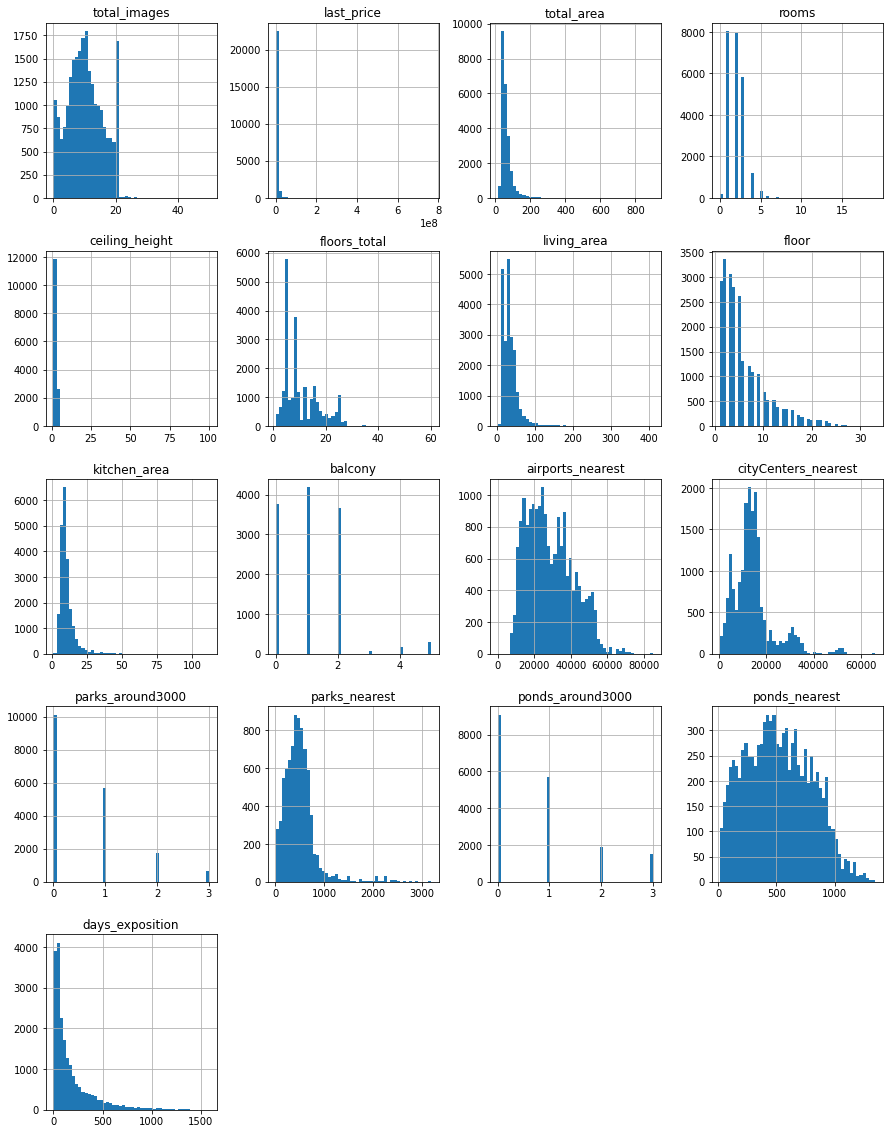

In [4]:
# Построим гистограммы для первичной визуальной оценки численных данных
data.hist(bins = 50, figsize=(15,20));

### Выводы

Всего 23699 записей, проблем с названием колонок нет, видны пропуски в данных и неподходящий формат некоторых столбцов:

- `airports_nearest` — есть пропуски

- `balcony` — есть пропуски, формат float64 необходимо преобразовать в int64

- `ceiling_height` — есть пропуски, и выбросы (возможно высота не в м, а в см)

- `cityCenters_nearest` — есть пропуски

- `days_exposition` — есть пропуски, формат float64 необходимо преобразовать в int64

- `first_day_exposition` — формат object необходимо преобразовать в datetime

- `floor` — все в порядке

- `floors_total` — есть пропуски, формат float64 необходимо преобразовать в int64, возможно выбросы

- `is_apartment` — есть пропуски, много, формат object необходимо преобразовать в boolean

- `kitchen_area` — есть пропуски, выбросы, ошибка или пропущена точка в метраже

- `last_price` — есть выбросы, возможно элитное жилье, либо ошибки

- `living_area` — есть пропуски, возможно выбросы

- `locality_name` — есть пропуски

- `open_plan` — все в порядке

- `parks_around3000` — есть пропуски, формат float64 необходимо заменить на int64, выбросов нет

- `parks_nearest` — есть пропуски

- `ponds_around3000` — есть пропуски, формат float64 необходимо заменить на int64, выбросов нет

- `ponds_nearest` — есть пропуски

- `rooms` — есть выбросы

- `studio` — все в порядке

- `total_area` — есть выбросы, возможно ошибки, например пропущена точка

- `total_images` — на первый взгляд все в порядке

## Предобработка данных

### Работа с пропусками и дубликатами, преобразование типов данных

In [5]:
# Посчитаем количество пропусков в данных по столбцам
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

#### Парки и пруды

In [6]:
#Посмотрим первые 10 строк, в которых вписано количество парков, но при этом пропщуена информация о расстоянии до них
data[data['parks_nearest'].isna() & ~data['parks_around3000'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
6,6,3700000.0,37.3,2017-11-02T00:00:00,1,NaN,26.0,10.6,6,NaN,False,False,14.4,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.6,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.9,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
9,18,5400000.0,61.0,2017-02-26T00:00:00,3,2.50,9.0,43.6,7,NaN,False,False,6.5,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0
11,9,3300000.0,44.0,2018-08-27T00:00:00,2,NaN,5.0,31.0,4,False,False,False,6.0,1.0,Ломоносов,48252.0,51677.0,0.0,NaN,0.0,NaN,7.0
14,1,4400000.0,36.0,2016-06-23T00:00:00,1,NaN,6.0,17.0,1,NaN,False,False,8.0,0.0,Пушкин,20782.0,30759.0,0.0,NaN,1.0,96.0,203.0
17,6,4180000.0,36.0,2016-09-09T00:00:00,1,NaN,17.0,16.5,7,NaN,False,False,11.0,1.0,Санкт-Петербург,33564.0,14616.0,0.0,NaN,1.0,859.0,571.0
19,16,14200000.0,121.0,2019-01-09T00:00:00,3,2.75,16.0,76.0,8,NaN,False,False,12.0,NaN,Санкт-Петербург,38900.0,12843.0,0.0,NaN,0.0,NaN,97.0
20,12,6120000.0,80.0,2017-09-28T00:00:00,3,2.70,27.0,48.0,11,NaN,False,False,12.0,2.0,посёлок Парголово,53134.0,19311.0,0.0,NaN,0.0,NaN,74.0
25,3,6800000.0,76.0,2015-10-01T00:00:00,2,2.75,23.0,39.0,18,False,False,False,15.0,2.0,Санкт-Петербург,34967.0,14640.0,0.0,NaN,1.0,564.0,300.0


In [7]:
# Посчитаем количество пропусков в количестве парков по условию выше
data[data['parks_nearest'].isna() & ~data['parks_around3000'].isna()]['parks_around3000'].isna().sum()

0

In [8]:
# Посмотрим сколько есть строк, с пропущенным колиечством парков и указанным расстоянием до ближайшего
data[~data['parks_nearest'].isna() & data['parks_around3000'].isna()].head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition


In [9]:
# Посчитаем количество пропусков в количестве парков по условию выше
data[data['ponds_nearest'].isna() & ~data['ponds_around3000'].isna()]['ponds_around3000'].isna().sum()

0

In [10]:
# Посмотрим сколько есть строк, с пропущенным колиечством парков и указанным расстоянием до ближайшего
data[~data['ponds_nearest'].isna() & data['ponds_around3000'].isna()].head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition


In [11]:
# Заменим пропуски в количестве парков < 3 км нулями и преобразуем в int
data['parks_around3000'] = data['parks_around3000'].fillna(0).astype('int')

# Заменим пропуски в количестве водоемов < 3 км нулями и преобразуем в int
data['ponds_around3000'] = data['ponds_around3000'].fillna(0).astype('int')

**Вывод:** видно, что есть строки с количеством парков 0 и пропущенным расстоянием до них по очевидной причине. Кроме того отсутствуют строки, в которых было пропущено количество парков и было указано расстояние. Поэтому заменяем пропуски в колиечстве парков нулями. Аналагичная ситуция для количества водоемов, так как эти данные были собраны автоматически. Заменили пропуски в количестве парков и прудов < 3 км нулями и преобразовали в int

#### Балконы

In [12]:
print(data['balcony'].isna().sum())
data['balcony'].describe() # есть пропуски и есть нули, вероятно пользователи не указал количество балконов

11519


count    12180.000000
mean         1.150082
std          1.071300
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: balcony, dtype: float64

In [13]:
# Заменим пропуски в количестве балконов нулями и преобразуем в int64
data['balcony'] = data['balcony'].fillna(0).astype('int')

**Вывод:** есть пропуски и есть нули, но каких=то выбросов нет, скорее всего продавцы не указали 0. В другом случае указали бы число, так как балкон - преимущество. Преобразовали в int

#### Количество этажей в доме

In [14]:
data['floors_total'].isna().sum()

86

In [15]:
# Выбросим 86 пропусков и преобразуем в int
data = data.query('~floors_total.isnull()')
data['floors_total'] = data['floors_total'].astype('int')

**Вывод:** 86 объявлений с пропусками этажности из 23699 выбросили, преобразовали в int

#### Дата выставления объявления на продажу

In [16]:
# Преобразуем дату выставления на продажу в datetime
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format = '%Y-%m-%d')

#### Количество дней размещения объявления до снятия

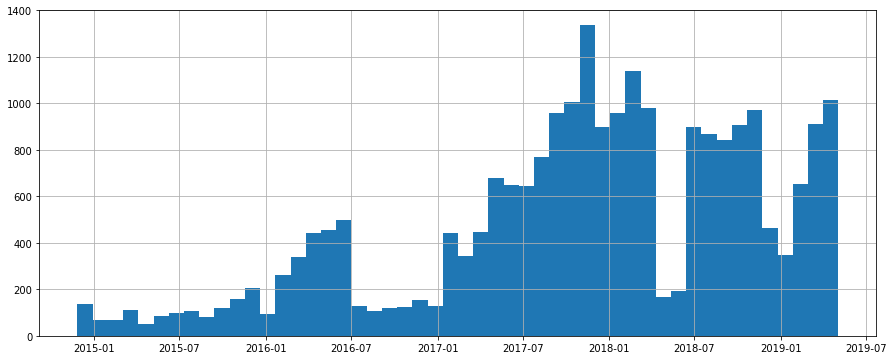

In [17]:
data['first_day_exposition'].hist(bins=50, figsize=(15,6)); # видно, что нет объявлений после мая 2019 года

In [18]:
data[data['days_exposition'].isna()]['first_day_exposition'].unique()

array(['2019-03-07T00:00:00.000000000', '2019-04-18T00:00:00.000000000',
       '2018-11-18T00:00:00.000000000', '2018-12-02T00:00:00.000000000',
       '2019-01-31T00:00:00.000000000', '2018-11-22T00:00:00.000000000',
       '2017-09-22T00:00:00.000000000', '2019-03-27T00:00:00.000000000',
       '2018-12-27T00:00:00.000000000', '2019-03-13T00:00:00.000000000',
       '2019-04-23T00:00:00.000000000', '2019-04-09T00:00:00.000000000',
       '2019-03-23T00:00:00.000000000', '2017-10-30T00:00:00.000000000',
       '2019-02-07T00:00:00.000000000', '2019-04-06T00:00:00.000000000',
       '2019-03-10T00:00:00.000000000', '2019-04-29T00:00:00.000000000',
       '2018-08-20T00:00:00.000000000', '2019-02-27T00:00:00.000000000',
       '2019-03-20T00:00:00.000000000', '2018-07-11T00:00:00.000000000',
       '2019-02-28T00:00:00.000000000', '2019-04-08T00:00:00.000000000',
       '2017-04-11T00:00:00.000000000', '2019-03-08T00:00:00.000000000',
       '2019-03-14T00:00:00.000000000', '2019-03-30

Однако есть даты публикации и более ранние, значит предположение о пропусках из-за публикации в день сбора данных неверно

In [19]:
data['days_exposition'].min()

1.0

1 день - минимальное количество дней, значит все-таки это объявления с 0 дней в публикации. Заменим пропуски нулями.

In [20]:
data['days_exposition'] = data['days_exposition'].fillna(0)

In [21]:
# Преобразуем в int
data['days_exposition'].astype(int)

0          0
1         81
2        558
3        424
4        121
        ... 
23694      0
23695     45
23696      0
23697    602
23698      0
Name: days_exposition, Length: 23613, dtype: int64

**Вывод:** заменили пропуски в количестве дней размещения нулями, так как они сущетсвовали меньше дня. Скорее всего связано с премодерацией или неподтверждением пользователем. Но, возможно, среди них были и продажи. Разделить нет возможности.

#### Апартаменты

In [22]:
print(data['is_apartment'].isna().count())
data.query('is_apartment.isnull()').head()

23613


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,NaN,False,False,25.0,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,0.0
1,7,3350000.0,40.4,2018-12-04,1,NaN,11,18.6,1,NaN,False,False,11.0,2,посёлок Шушары,12817.0,18603.0,0,NaN,0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20,2,NaN,5,34.3,4,NaN,False,False,8.3,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558.0
3,0,64900000.0,159.0,2015-07-24,3,NaN,14,NaN,9,NaN,False,False,NaN,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.0,13,NaN,False,False,41.0,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121.0


In [23]:
# Заменим пропуски в столбце апартаменты нулями и преобразуем в boolean
data['is_apartment'] = data['is_apartment'].fillna(0).astype('bool')

**Вывод:** пропуски в графе апартаменты вероятно связаны с тем, что многие не знают в чем разница между ними и квартирой. Заполним нулями и преобразуем в boolean

#### Название поселения

In [24]:
# Заменим часть пропусков в названии города по условию наличия города с одинковым расстоянием до аэропорта и центра города
# Будем использовать связку координат для индекса при заполнении пропусков
data['airport_cityCenter'] = list(zip(data['airports_nearest'], data['cityCenters_nearest'])) # добавим вспомогательный столбец
locality_name_wo_NaN = pd.pivot_table(data, 
                   values='balcony', 
                   index = ['airport_cityCenter', 'airports_nearest','cityCenters_nearest', 'locality_name'], 
                   aggfunc='count', dropna=True
                  )
locality_name_wo_NaN = (locality_name_wo_NaN.drop('balcony', axis=1)
                        .reset_index()
                        .drop_duplicates(subset='airport_cityCenter')
                        .set_index('airport_cityCenter')
                       )
data = data.set_index('airport_cityCenter')
data['locality_name'] = data['locality_name'].fillna(locality_name_wo_NaN['locality_name'])
data = data.reset_index()

In [25]:
data['locality_name'].isna().sum()
# Оставшиеся пропуски выбросим (31 штука)
data = data.dropna(subset=['locality_name'])

**Вывод:** часть пропусков заменили названиями населенных пунктов аналогичными названиями поселений по связке расстояний (расстояние до аэропорта, расстояние до центра города) - 17 штук, 31 строку без названия отбросим

#### Работа с дубликатами в названии поселений

In [26]:
data.duplicated().sum() # явных дубликатов нет

0

In [27]:
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [28]:
# Исправим неявные дубликаты в названии локации объявления

# Создадим функцию по переимнованию названия поселения
def locality_name_fix(name):
    location_type_words_set = ['городско', 'типа', 'садово', 'некоммерч', 'товарищ', 'коттедж', 'при', 'железно', 'станции']
    name = name.replace('ё', 'е')
    name = ' '.join([x for x in name.split() if not any(x.startswith(y) for y in location_type_words_set)])
    return name

# Исправим неявные дубликаты в названии локации объявления
data = data.dropna(subset=['locality_name'])
data['locality_name'] = data['locality_name'].apply(locality_name_fix)

In [29]:
data['locality_name'].unique()

array(['Санкт-Петербург', 'поселок Шушары', 'поселок Янино-1',
       'поселок Парголово', 'поселок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок Красный Бор', 'Гатчина', 'деревня Федоровское', 'Выборг',
       'Кронштадт', 'Кировск', 'деревня Новое Девяткино',
       'поселок Металлострой', 'поселок Лебяжье', 'поселок Сиверский',
       'поселок Молодцово', 'поселок Кузьмоловский', 'Новая Ропша',
       'Павловск', 'деревня Пикколово', 'Всеволожск', 'Волхов',
       'Кингисепп', 'Приозерск', 'Сестрорецк', 'деревня Куттузи',
       'поселок Аннино', 'поселок Ефимовский', 'поселок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'поселок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', 'поселок Новый Свет', 'Сланцы',
       'село Путилово', 'Ивангород', 'Мурино', 'Шлиссельбург',
       'Никольское', 'Зеленогорск', 'Сосновый Бор', 'дер

**Вывод:** Явных дубликатов нет. Неявные дубликаты исправлены. Посёлок -> поселок, поселок городского типа -> поселок, коттеджный поселок -> поселок и т.д. Остались типы: поселок, село, деревня, название без типа.

#### Площаль кухни и жилая площадь

In [30]:
# Пропуски в площади кухни или жилой не связаны с фактом студии
data.query('studio==True & (kitchen_area.isnull() or living_area.isnull())').head(10)

,airport_cityCenter,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
144,"(nan, nan)",1,2450000.0,27.00,2017-03-30,0,NaN,24,15.50,2,False,True,False,NaN,2,поселок Мурино,NaN,NaN,0,NaN,0,NaN,181.0
438,"(38171.0, 15015.0)",8,2480000.0,27.11,2018-03-12,0,NaN,17,24.75,4,False,True,False,NaN,2,Санкт-Петербург,38171.0,15015.0,0,NaN,2,982.0,64.0
605,"(nan, nan)",2,1850000.0,25.00,2019-02-20,0,NaN,10,NaN,7,False,True,False,NaN,0,поселок Шушары,NaN,NaN,0,NaN,0,NaN,29.0
693,"(nan, nan)",12,2500000.0,24.10,2017-12-01,0,2.75,25,17.50,21,False,True,False,NaN,0,деревня Кудрово,NaN,NaN,0,NaN,0,NaN,201.0
712,"(18654.0, 29846.0)",5,1500000.0,17.00,2017-06-07,0,2.70,9,12.00,1,False,True,False,NaN,0,поселок Шушары,18654.0,29846.0,0,NaN,0,NaN,40.0
1169,"(35129.0, 16293.0)",12,3240000.0,29.00,2018-10-30,0,NaN,24,17.00,2,False,True,False,NaN,2,Санкт-Петербург,35129.0,16293.0,0,NaN,1,475.0,13.0
1170,"(44754.0, 8409.0)",3,3900000.0,32.00,2016-10-18,0,2.70,24,18.00,2,False,True,False,NaN,2,Санкт-Петербург,44754.0,8409.0,1,609.0,0,NaN,540.0
1216,"(12507.0, 12419.0)",5,3300000.0,27.00,2017-11-10,0,2.80,17,20.00,16,False,True,False,NaN,0,Санкт-Петербург,12507.0,12419.0,0,NaN,1,528.0,113.0
1256,"(nan, nan)",0,2600000.0,27.00,2018-07-20,0,2.70,16,16.00,4,False,True,False,NaN,2,Кудрово,NaN,NaN,0,NaN,0,NaN,102.0
1273,"(48847.0, 16685.0)",10,3150000.0,26.00,2017-07-14,0,2.75,21,17.38,11,False,True,False,NaN,0,Санкт-Петербург,48847.0,16685.0,0,NaN,0,NaN,622.0


**Вывод:** трогать не будем, так как связи какой-то нет, пользователи просто не указали. Аналогично и общая площадь квартиры.

#### Расстояния до центра города и аэропорта

In [31]:
# Посчитаем количество пропусков в расстоянии до центра города и аэропорта при указанном городе СПб - мало 25        
data.query('airports_nearest.isnull() & locality_name == "Санкт-Петербург"')['rooms'].count()
data.query('cityCenters_nearest.isnull() & locality_name == "Санкт-Петербург"')['rooms'].count()

60

In [32]:
# Добавим расстояния до центра города и аэропорта, там где это возможно через геоданные

# Соберем все уникальные названия городов с пропусками расстояний
cities_Nan_airport_center = data.query(
    '''
    airports_nearest.isnull() and cityCenters_nearest.isnull() and locality_name!="Санкт-Петербург"
    '''
)['locality_name'].unique()

coordinates = []
centre_coordinates = (59.946216, 30.311475) # Координаты центра Санкт-Петербурга
airport_coordinates = (59.7998772, 30.2733421) # Координаты аэропорта Пулково
location_type_words = ['поселок', 'деревня', 'село'] # Иногда не находит с типом поселения перед его названием, уберем дальше
geolocator = Nominatim(user_agent='Yandex')

for city in cities_Nan_airport_center:
    try:
        location_name = 'Ленинградская область ' + city # добавим префикс Ленинградская область от дубликатов в других областях
        location = geolocator.geocode(location_name) 
        
        if location is None: # если не нашел, попробуем убрать тип поселения из названия
            pure_name_array = [word for word in city.split() if word not in location_type_words]
            pure_name = ' '.join(pure_name_array)
            location_name = 'Ленинградская область ' + pure_name
            location = geolocator.geocode(location_name)
            
            if location is None: # поселение может относиться к СПб, а не к области
                location_name = 'Санкт-Петербург ' + pure_name
                location = geolocator.geocode(location_name)
            
        coordinates.append((location.latitude, location.longitude))
        
    except:
        coordinates.append(np.NaN)

# Создадим датафрейм из названий и найденных координат, уберем пропуски, там где координаты не были найдены
cities_with_NaN_airport_center = pd.DataFrame({'city':cities_Nan_airport_center, 'coords':coordinates})
cities_with_NaN_airport_center = cities_with_NaN_airport_center.dropna().reset_index(drop=True)

cities_with_NaN_airport_center['cityCenters_nearest'] = cities_with_NaN_airport_center['coords'].apply(
                                                        lambda x: distance.distance(x, centre_coordinates).m)
cities_with_NaN_airport_center['airports_nearest'] = cities_with_NaN_airport_center['coords'].apply(
                                                        lambda x: distance.distance(x, airport_coordinates).m)

# Заполним пропуски в оригинальной таблице. Индекс - названия поселения, с помощью fillna()
cities_with_NaN_airport_center = cities_with_NaN_airport_center.set_index('city')
data = data.set_index('locality_name')
data['airports_nearest'] = data['airports_nearest'].fillna(cities_with_NaN_airport_center['airports_nearest'])
data['cityCenters_nearest'] = data['cityCenters_nearest'].fillna(cities_with_NaN_airport_center['cityCenters_nearest'])
data = data.reset_index()
data.isna().sum()
data = data.dropna(subset=['airports_nearest', 'cityCenters_nearest']) # выбросим поселения без координат, 86 штук
data = data.drop(data[data.cityCenters_nearest > 500000].index) # в анализе позже обнаружился один выброс за 2000км эхехе

**Вывод:** пропуски в расстояниях до центра города и аэропорта заполнены расстояниями с помощью геолокационного пакета geopy и Гео Яндекса.

In [33]:
data.isna().sum()

locality_name               0
airport_cityCenter          0
total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9056
floors_total                0
living_area              1846
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area             2204
balcony                     0
airports_nearest            0
cityCenters_nearest         0
parks_around3000            0
parks_nearest           15466
ponds_around3000            0
ponds_nearest           14443
days_exposition             0
dtype: int64

#### Высота потолка

Повторим трюк с связкой расстояний, только увеличим охват в + и - 100м по каждой, так как в одном районе в СПб сильного разброса по высоте потолка не должно быть. Заменим пропуск медианным значений для большей уверенности.

In [34]:
# Заменим часть пропусков в высоте потолка медианным значением по дому 
# по условию одинакового расстояния от дома до аэропорта и центра города
# Для сокращения времени, сделаем это через numpy, а не через цикл в pandas
ceiling_height_nan = data[data['ceiling_height'].isna() & \
                          ~data['airports_nearest'].isna() & \
                          ~data['cityCenters_nearest'].isna()]
ceiling_heights = data[~data['ceiling_height'].isna() & \
                       ~data['airports_nearest'].isna() & \
                       ~data['cityCenters_nearest'].isna()]['ceiling_height'].values
#Расстояния из выборки с пропусками высоты потолков
airport_distance = ceiling_height_nan['airports_nearest'].values
cityCenters_distance = ceiling_height_nan['cityCenters_nearest'].values
# Расстояния из общей выборки без пропусков
first = data[~data['ceiling_height'].isna() & \
             ~data['airports_nearest'].isna() & \
             ~data['cityCenters_nearest'].isna()]['airports_nearest'].values
second = data[~data['ceiling_height'].isna() & \
              ~data['airports_nearest'].isna() & \
              ~data['cityCenters_nearest'].isna()]['cityCenters_nearest'].values

# Создадим матрицу индексов попадания в наши лимиты по связке расстояний
within_range_indices = np.where(
    (np.abs(first[:, np.newaxis] - airport_distance) <= 100) &
    (np.abs(second[:, np.newaxis] - cityCenters_distance) <= 100)
)

# Заполним массив в том же порядке, что и в выборке с пропусками, где значение не найдено - заполним NaN
median_ceiling_heights = []
for i in range(len(ceiling_height_nan)):
    nearby_indices = within_range_indices[0][within_range_indices[1]==i]
    nearby_ceiling_heights = ceiling_heights[nearby_indices]
    if nearby_ceiling_heights.size != 0:
        median_cealing_height = np.median(nearby_ceiling_heights)
        median_ceiling_heights.append(median_cealing_height)
    else:
        median_ceiling_heights.append(np.NaN)

# Ругается на эту строчку, так как надо сбросить индексы, но делать это не будем, чтобы облегчить запись обратно в датафрейм
ceiling_height_nan['median_ceiling_heights'] = median_ceiling_heights
data['ceiling_height'] = data['ceiling_height'].fillna(ceiling_height_nan['median_ceiling_heights'])

/tmp/ipykernel_156/1775192661.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ceiling_height_nan['median_ceiling_heights'] = median_ceiling_heights


In [35]:
# Проверим количество пропусков после замен и преобразований
data.isna().sum()

locality_name               0
airport_cityCenter          0
total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height            735
floors_total                0
living_area              1846
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area             2204
balcony                     0
airports_nearest            0
cityCenters_nearest         0
parks_around3000            0
parks_nearest           15466
ponds_around3000            0
ponds_nearest           14443
days_exposition             0
dtype: int64

**Вывод:** большая удача, большая часть пропусков (7.5 тыс) заполнена медианным значением высот потолков по связке расстояний с допуском в +- 100м, хотя идея довольно рискованная, меньше взять - больше пропусков останется, больше - статистика разамжется. 100м - оптимально.

### Работа с явными аномалиями

#### `last_price`

count    2.347800e+04
mean     6.505942e+06
std      1.084195e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.610000e+06
75%      6.750000e+06
max      7.630000e+08
Name: last_price, dtype: float64

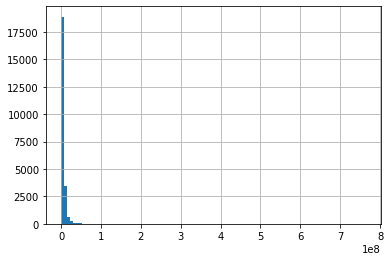

In [36]:
#посмотрим на явные аномалии
# last_price
data['last_price'].hist(bins=100)
data['last_price'].describe() # min = 12190 rub

In [37]:
print('Квартир меньше 200 тыс. рублей - ', data.query('last_price < 200000')['last_price'].count()) # только одно значение - выбросим
print('Квартир больше 50 млн. рублей - ', data.query('last_price > 50000000')['last_price'].count())
data = data.query('last_price < 50000000')

Квартир меньше 200 тыс. рублей -  1
Квартир больше 50 млн. рублей -  127


**Вывод:** Аномальные 127 квартир > 50 млн, выбросим. Минимальное за 12к выбросим

#### `total_area`

count    23344.000000
mean        59.095475
std         30.753857
min         12.000000
25%         40.000000
50%         52.000000
75%         69.000000
max        494.100000
Name: total_area, dtype: float64

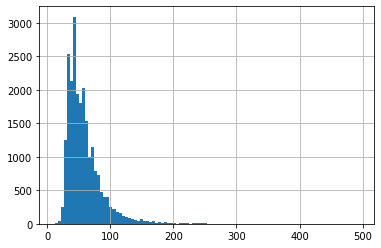

In [38]:
# total_area
data['total_area'].hist(bins=100)
data['total_area'].describe() # 900 квадратов максимальное значение

In [39]:
data = data.query('total_area < 200') # отбрасываем объявления > 200 млн

**Вывод:** выбросим объявления с площадью больше 200 кв.м.

#### `rooms`

In [40]:
data['rooms'].describe() # есть нулевые значения

count    23199.000000
mean         2.030734
std          0.993016
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: rooms, dtype: float64

In [41]:
data.query('rooms==0 & studio==True')['studio'].count() # это студии, заполним комнаты в пропусках 1, оставшиеся выбросим

135

In [42]:
data.loc[data.studio==True, ['rooms']] = 1

**Вывод:** 121 нулевое значение заполнили 1, так как это студии. Оставшиеся нулевые значения - выбросим

#### `ceiling_height`

In [43]:
data['ceiling_height'].describe() # есть потолки <2м и >10м, в первом случае могли точку поставить, а во втором наоборот

count    22476.000000
mean         2.742346
std          1.070978
min          1.000000
25%          2.550000
50%          2.650000
75%          2.760000
max        100.000000
Name: ceiling_height, dtype: float64

In [44]:
data.query('ceiling_height < 2.3')['ceiling_height'].count() # при мин норме 2.4м есть 14 квартир с потолком ниже 2.3, выбросим

17

In [45]:
print(data.query('ceiling_height > 23')['ceiling_height'].count()) # квартиры с потолком больше 23м, поправим, /10
data['ceiling_height'] = np.where(data['ceiling_height'] > 23, data['ceiling_height'] / 10, data['ceiling_height'])

25


In [46]:
data.query('ceiling_height > 11')['ceiling_height'].count() # потолки больше 5 метров не нужны, уберем
data = data.query('ceiling_height < 5.1')

**Вывод:** есть потолки <2м и >10м, в первом случае могли точку поставить, а во втором наоборот. При минимальной норме 2.4м есть 16 квартир с потолком ниже 2.3, выбросим. 21 квартира с потолком больше 23м, поправим, поделим на 10. Потолки больше 5 метров уберем

#### `floors_total` и `floors`

In [47]:
# floors_total
data['floors_total'].describe() # вроде все нормально

count    22457.000000
mean        10.753930
std          6.602067
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

In [48]:
# floor
data['floor'].describe()
data.query('floor > floors_total').head(20) # все нормально

,locality_name,airport_cityCenter,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition


#### `living_area`

count    20739.000000
mean        33.168420
std         17.222914
min          2.000000
25%         18.500000
50%         30.000000
75%         42.000000
max        164.700000
Name: living_area, dtype: float64

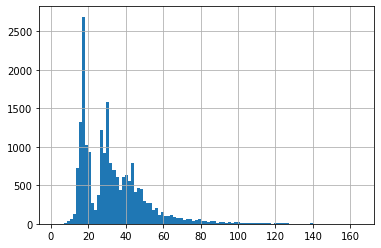

In [49]:
data['living_area'].hist(bins=100)
data['living_area'].describe()

In [50]:
data.query('living_area < 8').count() # меньше 8 квадратов 7 квартир, норма 14м, выбросим

locality_name           7
airport_cityCenter      7
total_images            7
last_price              7
total_area              7
first_day_exposition    7
rooms                   7
ceiling_height          7
floors_total            7
living_area             7
floor                   7
is_apartment            7
studio                  7
open_plan               7
kitchen_area            5
balcony                 7
airports_nearest        7
cityCenters_nearest     7
parks_around3000        7
parks_nearest           4
ponds_around3000        7
ponds_nearest           2
days_exposition         7
dtype: int64

In [51]:
data = data.query('living_area > 7') # общая площадь при этом адеквтаная, оставим, но запомним

**Вывод:** меньше 8 квадратов 7 квартир, норма 14м, выбросим

#### `kitchen_area`

count    19983.000000
mean        10.285387
std          5.115513
min          1.300000
25%          7.000000
50%          9.000000
75%         11.800000
max         75.000000
Name: kitchen_area, dtype: float64

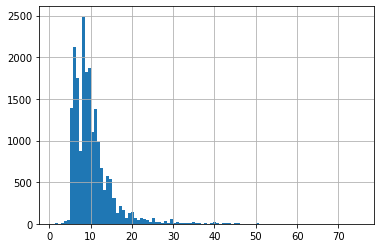

In [52]:
# kitchen_area
data['kitchen_area'].hist(bins=100)
data['kitchen_area'].describe()

In [53]:
data.query('kitchen_area < 3').count() # меньше 3 квадратов 11 кухонь, норма 8м, но это опять же Питер

locality_name           11
airport_cityCenter      11
total_images            11
last_price              11
total_area              11
first_day_exposition    11
rooms                   11
ceiling_height          11
floors_total            11
living_area             11
floor                   11
is_apartment            11
studio                  11
open_plan               11
kitchen_area            11
balcony                 11
airports_nearest        11
cityCenters_nearest     11
parks_around3000        11
parks_nearest            2
ponds_around3000        11
ponds_nearest            6
days_exposition         11
dtype: int64

In [54]:
data = data.query('kitchen_area > 3') # выбросим эти 11 кухонь

**Вывод:** меньше 3 квадратов 11 кухонь, норма 8м, выбросим

#### `balcony`

In [55]:
# balcony
data['balcony'].describe() # все нормально

count    19965.000000
mean         0.627698
std          0.975139
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: balcony, dtype: float64

#### Выбросываем указанные аномалии

In [56]:
# выбрасываем все накопленное
data = data.drop(
    data[(data.last_price < 200000) | 
         (data.rooms == 0) | (data.rooms == 19) | 
         (data.ceiling_height < 2.3) | (data.ceiling_height > 11)].index
)

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19950 entries, 0 to 23574
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   locality_name         19950 non-null  object        
 1   airport_cityCenter    19950 non-null  object        
 2   total_images          19950 non-null  int64         
 3   last_price            19950 non-null  float64       
 4   total_area            19950 non-null  float64       
 5   first_day_exposition  19950 non-null  datetime64[ns]
 6   rooms                 19950 non-null  int64         
 7   ceiling_height        19950 non-null  float64       
 8   floors_total          19950 non-null  int64         
 9   living_area           19950 non-null  float64       
 10  floor                 19950 non-null  int64         
 11  is_apartment          19950 non-null  bool          
 12  studio                19950 non-null  bool          
 13  open_plan       

**Вывод:** осталось 19950 строк, пойдет

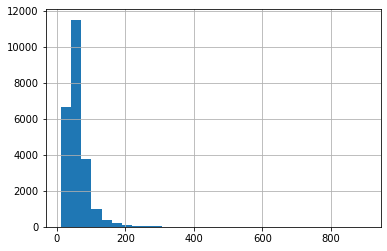

In [58]:
#код ревьюера
data2 = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
(data2['total_area']).hist(bins=30);

### Вспомогательные столбцы для удобства анализа

In [59]:
# Добавим столбец с ценой за квадратный метр в тыс. рублей
data['price_per_meter_thous'] = (data['last_price'] / (1000 * data['total_area'])).round(2)
data['last_price_mill'] = (data['last_price'] / 1000000).round(2) # И добавим столбец в млн рублей

# Категоризация даты публикации по дням недели: 0 — понедельник, 1 — вторник и так далее
data['weekday_exposition'] = data['first_day_exposition'].dt.weekday

# Категоризация даты публикации по месяцу
data['month_exposition'] = data['first_day_exposition'].dt.month

# Категоризация даты публикации по году
data['year_exposition'] = data['first_day_exposition'].dt.year

# Категоризация объявлений по этажу (первый, последний, другой)
# Создадим функцию категоризации
def floor_categorization(row):    
    if row['floor'] == 1:
        return 'Первый'
    elif (row['floor'] == row['floors_total']) & (row['floor'] > 1):
        return 'Последний'
    return 'Другой'

data['floor_category'] = data.apply(floor_categorization, axis=1)

# Расстояние до центра города в км
data['cityCenters_nearest_km'] = (data['cityCenters_nearest'] / 1000).round()
data.head()

,locality_name,airport_cityCenter,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_meter_thous,last_price_mill,weekday_exposition,month_exposition,year_exposition,floor_category,cityCenters_nearest_km
0,Санкт-Петербург,"(18863.0, 16028.0)",20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,False,False,25.0,0,18863.00000,16028.000000,1,482.0,2,755.0,0.0,120.37,13.00,3,3,2019,Другой,16.0
1,поселок Шушары,"(12817.0, 18603.0)",7,3350000.0,40.4,2018-12-04,1,2.70,11,18.6,1,False,False,False,11.0,2,12817.00000,18603.000000,0,NaN,0,NaN,81.0,82.92,3.35,1,12,2018,Первый,19.0
2,Санкт-Петербург,"(21741.0, 13933.0)",10,5196000.0,56.0,2015-08-20,2,2.60,5,34.3,4,False,False,False,8.3,0,21741.00000,13933.000000,1,90.0,2,574.0,558.0,92.79,5.20,3,8,2015,Другой,14.0
4,Санкт-Петербург,"(31856.0, 8098.0)",2,10000000.0,100.0,2018-06-19,2,3.03,14,32.0,13,False,False,False,41.0,0,31856.00000,8098.000000,2,112.0,1,48.0,121.0,100.00,10.00,1,6,2018,Другой,8.0
5,поселок Янино-1,"(nan, nan)",10,2890000.0,30.4,2018-09-10,1,2.65,12,14.4,5,False,False,False,9.1,0,24973.74053,15119.054345,0,NaN,0,NaN,55.0,95.07,2.89,0,9,2018,Другой,15.0


### Вывод

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19950 entries, 0 to 23574
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   locality_name           19950 non-null  object        
 1   airport_cityCenter      19950 non-null  object        
 2   total_images            19950 non-null  int64         
 3   last_price              19950 non-null  float64       
 4   total_area              19950 non-null  float64       
 5   first_day_exposition    19950 non-null  datetime64[ns]
 6   rooms                   19950 non-null  int64         
 7   ceiling_height          19950 non-null  float64       
 8   floors_total            19950 non-null  int64         
 9   living_area             19950 non-null  float64       
 10  floor                   19950 non-null  int64         
 11  is_apartment            19950 non-null  bool          
 12  studio                  19950 non-null  bool  

Осталось 19950  записей

- `airports_nearest` — пропуски - почти все места это поселения вне СПб, возникли из-за технических настроек фильтра, заполнены из геоданных по названию поселения, остатки выброшены

- `balcony` — пропуски явно из-за того, что пользователи не указали 0 как отсутствие балкона, формат float64 преобразован в int64 так как балконы счетные

- `ceiling_height` — исправлены значения потолков больше 23м, пользователи не поставили точку, выброшены потолки < 2.3м и > 11м, часть пропусков заполнена медианным значением высоты потолка в домах вблизи интересуемого дома +-100м по связке расстояния (аэропорт, центр города), отбросили потолки больше 5 метров

- `cityCenters_nearest` — пропуски - почти все места это поселения вне СПб, возникли из-за технических настроек фильтра, заполнены из геоданных по названию поселения, остатки выброшены

- `days_exposition` — заполнены нулями, так как не было объявлений менее 1 дня, возможно связано с модерацией или пользователи ошибались и сами удаляли объявления, либо в некоторых случаях факт продажи, формат float64 преобразован в int64 так как дни целые

- `first_day_exposition` — формат object преобразован в datetime для удобства работы с переменной

- `floor` — все в порядке

- `floors_total` — пропуски заполнены по связке расстояний (аэропорт, центр города) из домов, где этажность известна, float64 преобразован в int64 так как целые

- `is_apartment` — пропуски заполнены 0, так как не все понимают что такое апартаменты, либо старые объявления, формат object преобразован в boolean так как логическая переменная

- `kitchen_area` — пропуски без изменений < 10%, возможности заполнить нет, не критично, отброчили кухни меньше 3 кв.м.

- `last_price` — очень маленькая цена выброшена (12000р), квартиры больше 50 млн отбросили

- `living_area` — пропуски без изменений < 10%, возможности заполнить нет, не критично, жилая площадь меньше 8 квадратов отброшена

- `locality_name` — исправлены неявные дубликаты, пропуски заполнены по совпадению связки расстояний (аэропорт, центр города), остатки выброшены

- `open_plan` — все в порядке

- `parks_around3000` — пропуски заполнены 0 из-за отсутсвия парков, формат float64 заменен на int64 так как счетные

- `parks_nearest` — пропуски без изменений, так как отсутствуют парки, а значит и расстояния

- `ponds_around3000` — пропуски заполнены 0 из-за отсутсвия прудов, формат float64 заменен на int64 так как счетные

- `ponds_nearest` — пропуски без изменений, так как отсутствуют пруды, а значит и расстояния

- `rooms` — выбросы исправлены, там где не получилось - отброшены

- `studio` — все в порядке

- `total_area` — выбросы больше 200 кв.м. отброшены

- `total_images` — все в порядке

Были добавлены следующие столбцы:

- `price_per_meter_thous` — цена одного квадратного метра, рассчитан как цена / общую площадь

- `last_price_mill` — цена объекта в млн рублей

- `weekday_exposition` — день публикации объявления

- `month_exposition` — месяц публикации объявления

- `year_exposition` — год публикации объявления

- `floor_category` — категория этажа (первый, последний, другой)

- `cityCenters_nearest_km` — расстояние до центра в км

## Проведите исследовательский анализ данных

### Описание параметров

#### Общая площадь кваритры

In [61]:
# Сводка по общей площади квартиры
print('Медианная общая площадь - ', data['total_area'].median())
data['total_area'].describe() # из предобработки известно, что в выборке есть элитное жилье, отсюда большой максимум

Медианная общая площадь -  52.0


count    19950.000000
mean        58.373809
std         25.767642
min         20.000000
25%         40.300000
50%         52.000000
75%         69.000000
max        198.900000
Name: total_area, dtype: float64

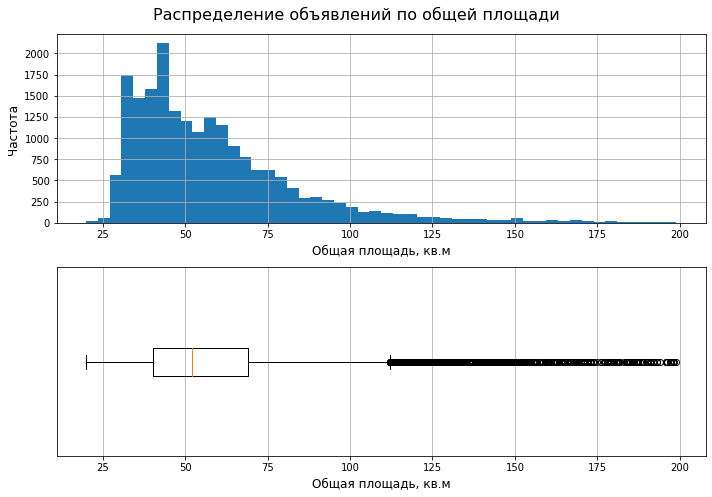

In [62]:
# Построим диаграммы распределения по общей площади
# Для вырванивания сделаем через сабплот
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по общей площади', size=16)
# Строим столбчатую диаграмму
axes[0].hist(data['total_area'], bins = 50)
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Общая площадь, кв.м', size=12)
axes[0].set_ylabel('Частота', size=12)
# Строим диаграмму рассеяния
axes[1].boxplot(data['total_area'], vert=False)
axes[1].grid()
#axes[1].tick_params(labelleft=False, length=0)
axes[1].set_yticks([])
axes[1].set_xlabel('Общая площадь, кв.м', size=12)
plt.tight_layout()

Похоже на распределение Пуассона с медианой 52 кв.м, наблюдаемый максимум ~ 110 кв.м, минимум - 20.

#### Жилая площадь

In [63]:
# Статистика по жилой площади
print('Медианная жилая площадь - ', data['living_area'].median())
data['living_area'].describe() # из предобработки известно, что в выборке есть элитное жилье, отсюда большой максимум

Медианная жилая площадь -  30.0


count    19950.000000
mean        33.397301
std         17.199305
min          8.000000
25%         18.700000
50%         30.000000
75%         42.100000
max        164.700000
Name: living_area, dtype: float64

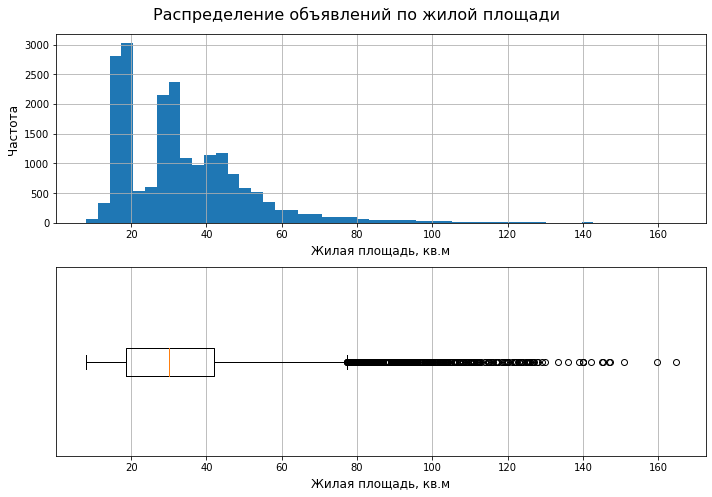

In [64]:
# Построим диаграммы распределения по жилой площади
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по жилой площади', size=16)

axes[0].hist(data['living_area'].dropna(), bins = 50) # Выбросим пропуски при построении диаграммы
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Жилая площадь, кв.м', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['living_area'].dropna(), vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Жилая площадь, кв.м', size=12)
plt.tight_layout()

На столбчатой диаграмме видно две моды - ~17 и ~32 квадратных метра, наблюдаемый максимум - 76 кв.м. минимум выберем 8 кв.м. Медианная жилая площадь - 30 кв.м

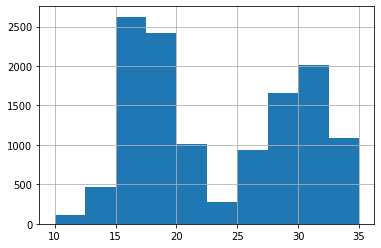

In [65]:
data['living_area'].hist(bins=10, range=[10,35]);

#### Площадь кухни

In [66]:
# Статистика по площади кухни
print('Медианная площадь кухни - ', data['kitchen_area'].median())
data['kitchen_area'].describe()

Медианная площадь кухни -  9.0


count    19950.000000
mean        10.292619
std          5.109007
min          3.200000
25%          7.000000
50%          9.000000
75%         11.800000
max         75.000000
Name: kitchen_area, dtype: float64

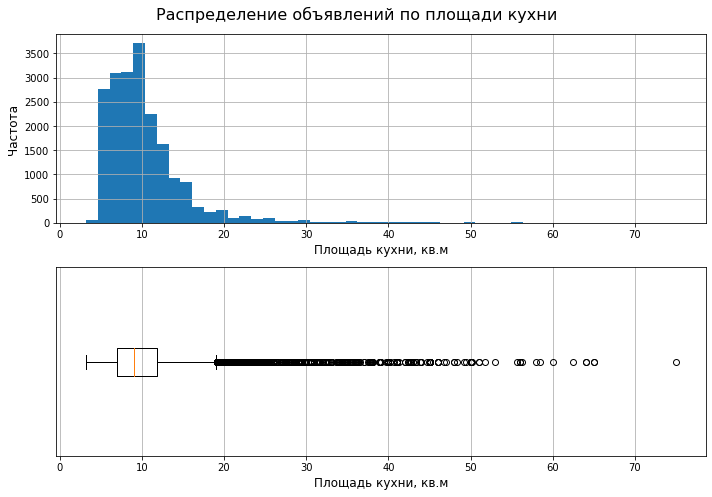

In [67]:
# Построим диаграммы распределения по площади кухни
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по площади кухни', size=16)

axes[0].hist(data['kitchen_area'].dropna(), bins = 50) # Выбросим пропуски при построении диаграммы
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Площадь кухни, кв.м', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['kitchen_area'].dropna(), vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Площадь кухни, кв.м', size=12)
plt.tight_layout()

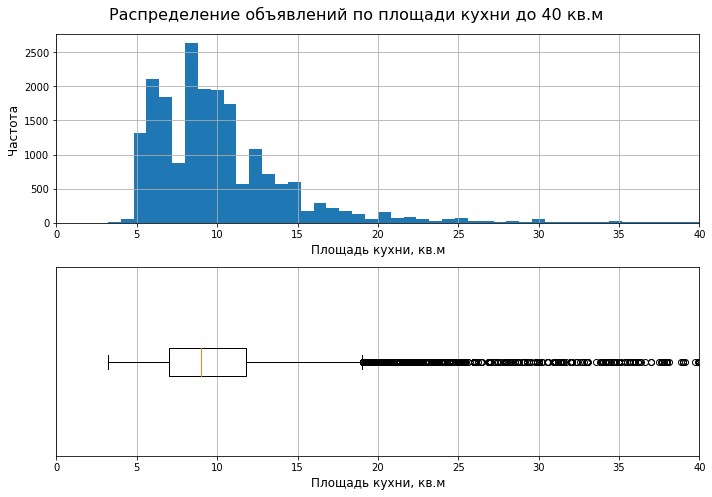

In [68]:
# Построим диаграммы распределения по площади кухни до 40 кв.м
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по площади кухни до 40 кв.м', size=16)

axes[0].hist(data['kitchen_area'].dropna(), bins = 50, range=[0,40]) # Выбросим пропуски при построении диаграммы и огранчим
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Площадь кухни, кв.м', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['kitchen_area'].dropna(), vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Площадь кухни, кв.м', size=12)
axes[1].set_xlim(0, 40)
plt.tight_layout()

Похоже на распределение Пуассона с медианой 9 кв.м и небольшим провалом в районе 6 кв.м, видимо промежуточных кухонь в СПб особо не бывает, наблюдаемый максимум - 19 кв.м, минимум примем за 8 кв.м.

#### Цена объекта

In [69]:
# Статистика по цене объекта
print('Медианная стоимость - ', data['last_price_mill'].median(), 'млн рублей')
data['last_price_mill'].describe()

Медианная стоимость -  4.65 млн рублей


count    19950.000000
mean         5.886606
std          4.501106
min          0.430000
25%          3.500000
50%          4.650000
75%          6.700000
max         49.900000
Name: last_price_mill, dtype: float64

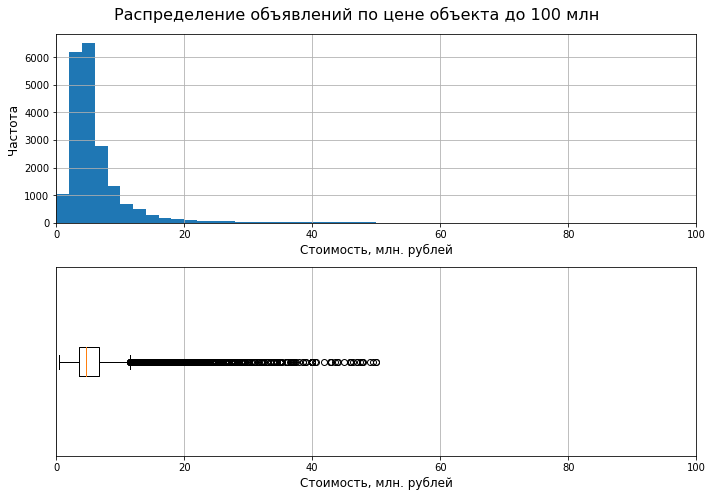

In [70]:
# Построим диаграммы распределения по цене объекта
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по цене объекта до 100 млн', size=16)

axes[0].hist(data['last_price_mill'], bins = 50, range=[0,100]) 
# Помня о выбросах и первичной диаграмме сразу ограничим 100 млн
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Стоимость, млн. рублей', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['last_price_mill'], vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Стоимость, млн. рублей', size=12)
axes[1].set_xlim(0, 100)
plt.tight_layout()

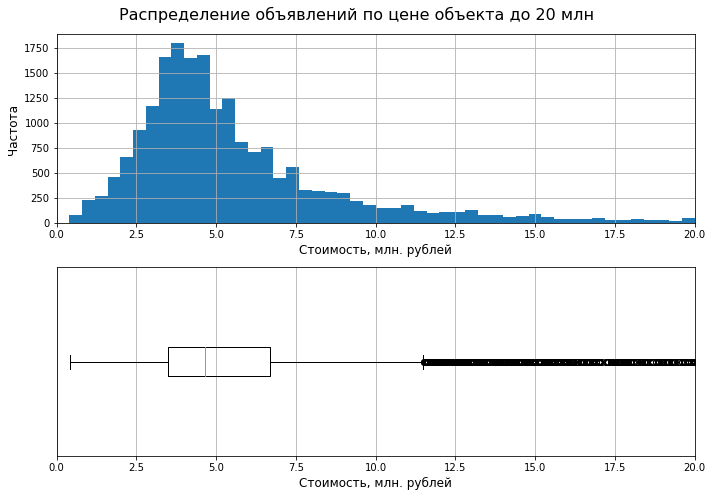

In [71]:
# Построим диаграммы распределения по цене объекта
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по цене объекта до 20 млн', size=16)

axes[0].hist(data['last_price_mill'], bins = 50, range=[0,20]) # Посомтрим до 20 млн
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Стоимость, млн. рублей', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['last_price_mill'], vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Стоимость, млн. рублей', size=12)
axes[1].set_xlim(0, 20)
plt.tight_layout()

Похоже на распределение Пуассона с медианой 4.65 млн. рублей, есть достаточно выбросов

#### Количество комнат

In [72]:
# Статистика по количеству комнат
print('Медианное количество комнат - ', data['rooms'].median())
data['rooms'].describe()

Медианное количество комнат -  2.0


count    19950.000000
mean         2.058897
std          0.980480
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: rooms, dtype: float64

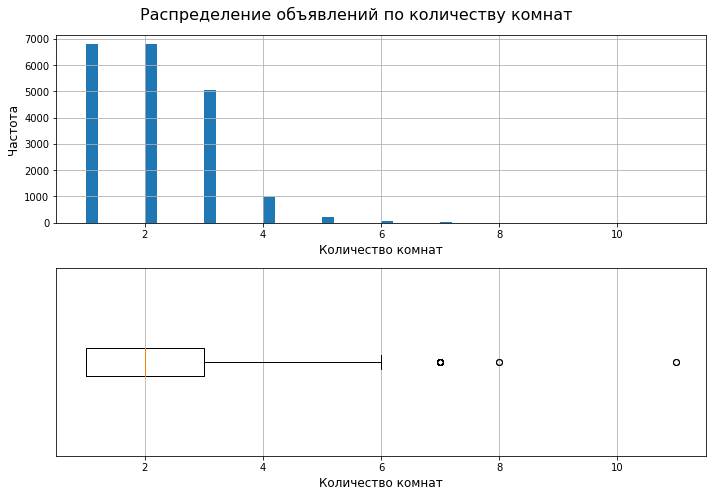

In [73]:
# Построим диаграммы распределения по количеству комнат
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по количеству комнат', size=16)

axes[0].hist(data['rooms'], bins = 50) # Выбросим пропуски при построении диаграммы
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Количество комнат', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['rooms'], vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Количество комнат', size=12)
plt.tight_layout()

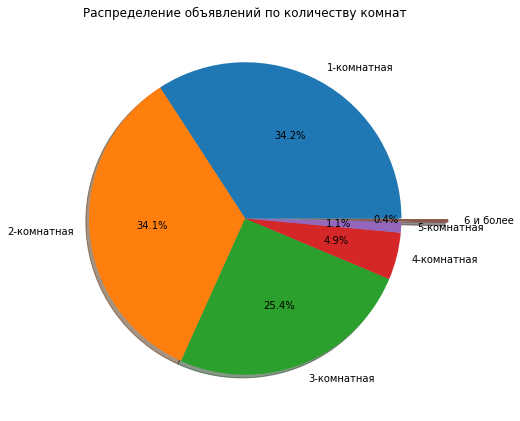

In [74]:
# Построим круговую диаграмму распределения по комнатам
def room_categorization(r):    
    if r == 1:
        return '1-комнатная'
    elif r == 2:
        return '2-комнатная'
    elif r == 3:
        return '3-комнатная'
    elif r == 4:
        return '4-комнатная'
    elif r == 5:
        return '5-комнатная'
    return '6 и более'

data['rooms'].apply(room_categorization).value_counts().plot(kind='pie', autopct='%1.1f%%', \
                                           explode=(0.0, 0.0, 0.0, 0.0, 0.0, 0.3), \
                                           shadow=True, startangle=0, yticks=([]), figsize=(7,17), \
                                           title='Распределение объявлений по количеству комнат').set_ylabel('');

Чаще всего встречаются 1-комнатные объекты и, с небольшим отставанием, 2-комнатные, в 7 раз реже - 4-комнатные, медианное количество комнат - 2, выбросы после 6 комнат. Медианное количество комнат - 2

#### Высота потолков

In [75]:
# Статистика по высоте потолков
print('Медианная высота потолков - ', data['ceiling_height'].median())
data['ceiling_height'].describe()

Медианная высота потолков -  2.65


count    19950.000000
mean         2.706121
std          0.239209
min          2.300000
25%          2.550000
50%          2.650000
75%          2.755000
max          4.800000
Name: ceiling_height, dtype: float64

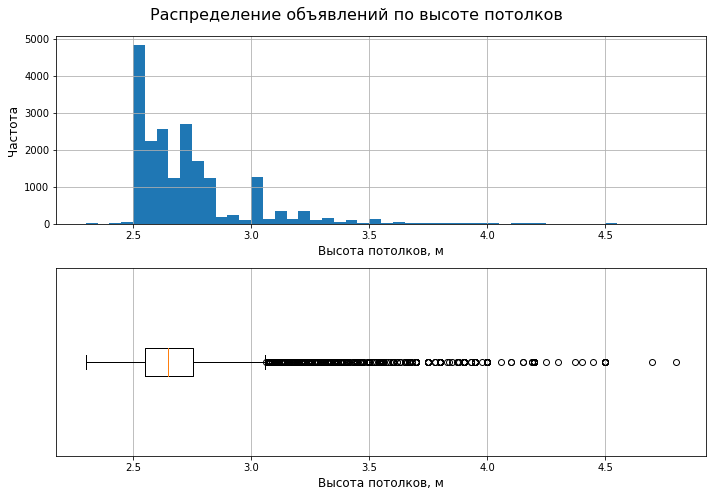

In [76]:
# Построим диаграммы распределения по высоте потолков
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по высоте потолков', size=16)

axes[0].hist(data['ceiling_height'].dropna(), bins = 50) # Выбросим пропуски при построении диаграммы
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Высота потолков, м', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['ceiling_height'].dropna(), vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Высота потолков, м', size=12)
plt.tight_layout()

Медианная высота потолка 2.65 м, примерно такое же количество потолков до 2.7 м, распределенных примерно с шагом 0.05 м, затем спад, провал и пик на 3.1 м, целых 1.2 тыс., есть достаточно выбросов

#### Тип этажа квартиры

In [77]:
# Статистика по типу этажа объекта
data['floor_category'].value_counts()

Другой       14713
Последний     2807
Первый        2430
Name: floor_category, dtype: int64

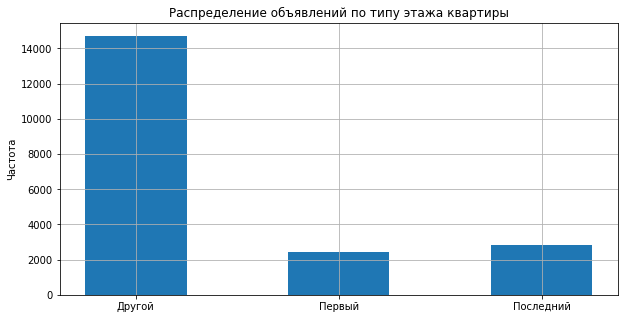

In [78]:
# Построим диаграммы распределения по типу этажа квартиры
data['floor_category'].hist(align='mid', bins = np.arange(4) - 0.5, rwidth=0.5, figsize=(10,5)).set_ylabel('Частота')
plt.title('Распределение объявлений по типу этажа квартиры');

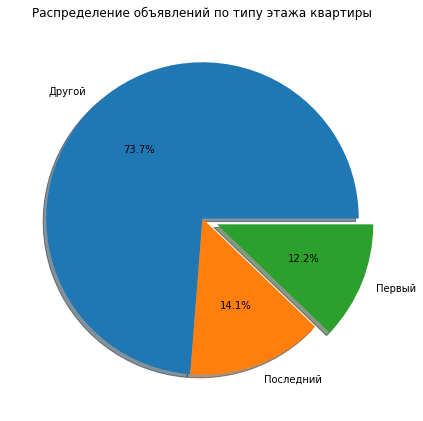

In [79]:
# Построим круговую диаграмму распределения по типу этажа квартиры
data['floor_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', explode=(0, 0, 0.1), \
                                           shadow=True, startangle=0, yticks=([]), figsize=(7,17), \
                                           title='Распределение объявлений по типу этажа квартиры').set_ylabel('');

73.7% объектов расположены между первым и последним этажами, меньше всего на первом - 12.2%

#### Общее количество этажей в доме

In [80]:
# Статистика по общему количеству этажей в доме
print('Медианное количество этажей в доме - ', data['floors_total'].median())
data['floors_total'].describe()

Медианное количество этажей в доме -  9.0


count    19950.000000
mean        10.636792
std          6.522637
min          1.000000
25%          5.000000
50%          9.000000
75%         15.000000
max         60.000000
Name: floors_total, dtype: float64

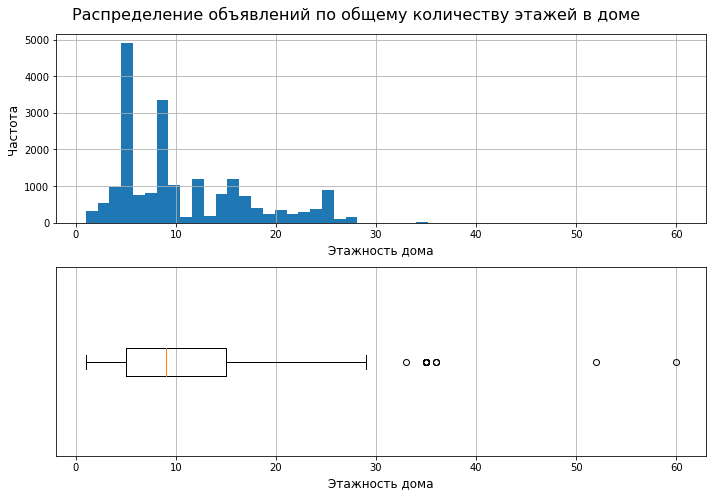

In [81]:
# Построим диаграммы распределения по общему количеству этажей в доме
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по общему количеству этажей в доме', size=16)

axes[0].hist(data['floors_total'], bins = 50)
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Этажность дома', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['floors_total'], vert=False)
axes[1].grid()
#axes[1].tick_params(labelleft=False, length=0)
axes[1].set_yticks([])
axes[1].set_xlabel('Этажность дома', size=12)
plt.tight_layout()

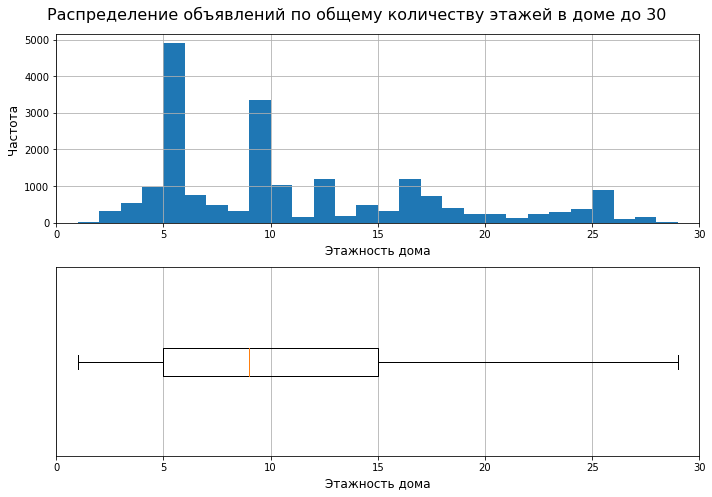

In [82]:
# Построим диаграммы распределения по высоте потолков до 5 м
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по общему количеству этажей в доме до 30', size=16)

axes[0].hist(data['floors_total'], bins = 30, range=[0,30])
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Этажность дома', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['floors_total'], vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Этажность дома', size=12)
axes[1].set_xlim(0, 30)
plt.tight_layout()

Медианное количество этажей в доме - 9, чаще всего встречаются пятиэтажки ~ 5 тыс. и девятиэтажки ~ 3.2 тыс., есть выбросы

#### Расстояние до центра города в метрах

In [83]:
# Статистика по расстоянию до центра города в метрах
print('Медианное расстояние до центра города в метрах - ', data['cityCenters_nearest'].median())
data['cityCenters_nearest'].describe()

Медианное расстояние до центра города в метрах -  14396.0


count     19950.000000
mean      23358.002139
std       29144.484288
min         181.000000
25%       11065.000000
50%       14396.000000
75%       21964.000000
max      253148.747504
Name: cityCenters_nearest, dtype: float64

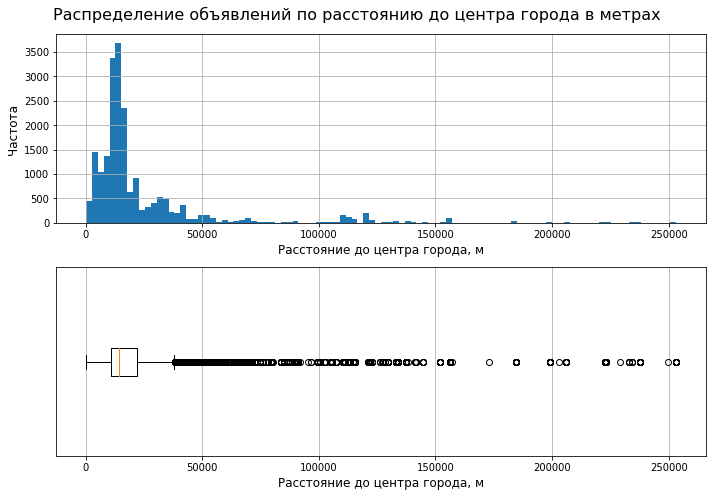

In [84]:
# Построим диаграммы распределения по расстоянию до центра города в метрах
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по расстоянию до центра города в метрах', size=16)

axes[0].hist(data['cityCenters_nearest'], bins = 100)
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Расстояние до центра города, м', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['cityCenters_nearest'], vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Расстояние до центра города, м', size=12)
plt.tight_layout()

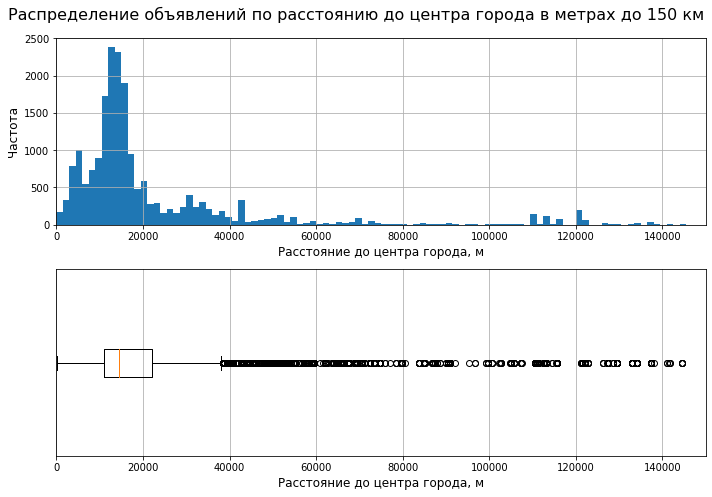

In [85]:
# Построим диаграммы распределения по расстоянию до центра города в метрах до 150 км
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по расстоянию до центра города в метрах до 150 км', size=16)

axes[0].hist(data['cityCenters_nearest'], bins = 100, range=[0,150000])
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Расстояние до центра города, м', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['cityCenters_nearest'], vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Расстояние до центра города, м', size=12)
axes[1].set_xlim(0, 150000)
plt.tight_layout()

Медианное расстояние до центра СПб - 14400 метров, похоже на распределение Пуассона, но есть провал в левом плече, и в правом хвосте есть крупные локальные выбросы - города под СПб

#### Расстояние до ближайшего парка

In [86]:
# Статистика по расстоянию до ближайшего парка в метрах
print('Медианное расстояние до ближайшего парка в метрах - ', data['parks_nearest'].median())
data['parks_nearest'].describe()

Медианное расстояние до ближайшего парка в метрах -  456.0


count    6815.000000
mean      491.310198
std       339.464254
min         1.000000
25%       289.000000
50%       456.000000
75%       613.000000
max      3190.000000
Name: parks_nearest, dtype: float64

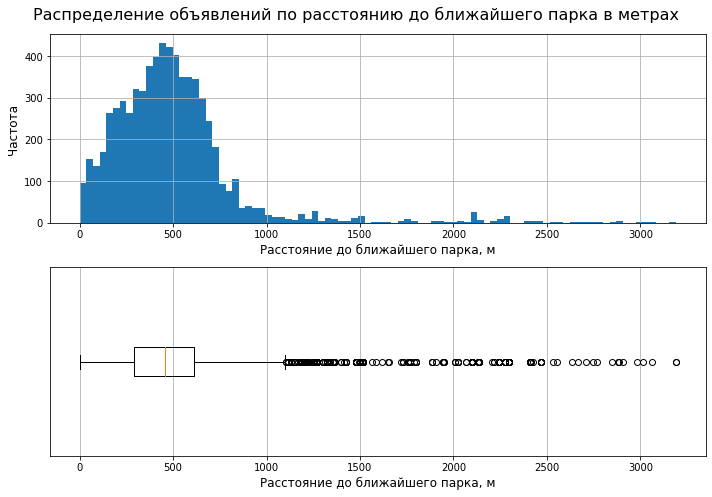

In [87]:
# Построим диаграммы распределения по расстоянию до ближайшего парка в метрах
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по расстоянию до ближайшего парка в метрах', size=16)

axes[0].hist(data['parks_nearest'].dropna(), bins = 90)
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Расстояние до ближайшего парка, м', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data['parks_nearest'].dropna(), vert=False)
axes[1].grid()
axes[1].set_yticks([])
axes[1].set_xlabel('Расстояние до ближайшего парка, м', size=12)
plt.tight_layout()

Медианное расстояние до ближайшего парка - 456 метров, похоже на распределение Пуассона, почти у всех объектов с наличием рядом парка, он находится в пределах 1 км, по выбросам понятно, что автоматом собираются парки в пределах 3.5 км. Получается, что почти в трети объявлений рядом будет парк (в СПб), за городом может быть лес.

#### Вывод

**Вывод по данному разделу:** Общий портрет медианного объекта: стоит 4.65 млн. рублей, в нем 1 или 2 комнаты с высотой потолка 2.65 метра, с площадью 52 кв.метра, жилая площадь - 17 или 32 кв.метра для однушки или двушки, с кухней площадью 6 или 9 кв.метров, расположен в 9- или 5-этажном доме между первым и последним этажом, находится в 14.4 км от центра СПб, и если есть парк (треть объявлений), то находится в 450 метрах от дома.

### Скорость продажи квартиры

#### Построим диаграммы распределения по длительности публикации

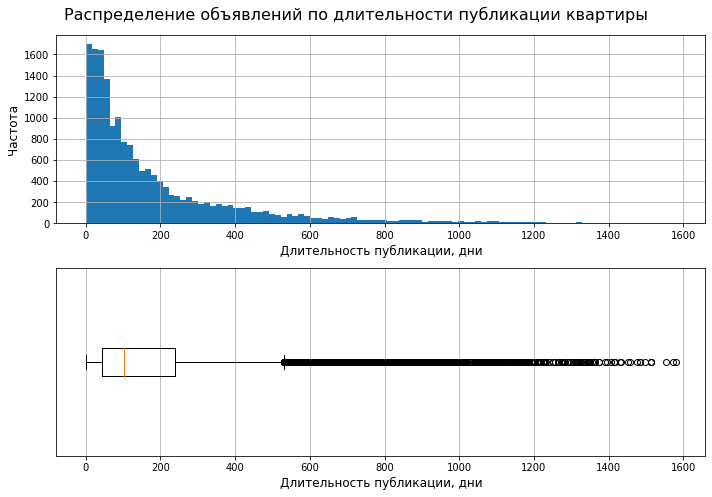

In [88]:
# Построим диаграммы распределения по длительности публикации
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7)) 
plt.suptitle('Распределение объявлений по длительности публикации квартиры', size=16)

axes[0].hist(data.query('days_exposition > 0')['days_exposition'], bins = 100)
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Длительность публикации, дни', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data.query('days_exposition > 0')['days_exposition'], vert=False)
axes[1].grid()
#axes[1].tick_params(labelleft=False, length=0)
axes[1].set_yticks([])
axes[1].set_xlabel('Длительность публикации, дни', size=12)
plt.tight_layout()

In [89]:
# Статистика по длительности публикации
print('Медианное количество дней публикации объявления о продаже - ', data.query('days_exposition > 0')['days_exposition'].median())
data.query('days_exposition > 0')['days_exposition'].describe()

Медианное количество дней публикации объявления о продаже -  102.0


count    17209.000000
mean       185.637167
std        222.021282
min          1.000000
25%         45.000000
50%        102.000000
75%        239.000000
max       1580.000000
Name: days_exposition, dtype: float64

Медианное число - 102 дня. Нулевые значения выставочных дней были отброшены, так как не до конца понятна их природа. Основное предположение - премодерация / подтверждение пользователем, без которого объявление удаляется. Есть висяки - квартиры в продаже больше 1.5 лет, такое может быть, их мало, но как выбросы, тоже их отбросим для задачи. Пусть будет 500 дней

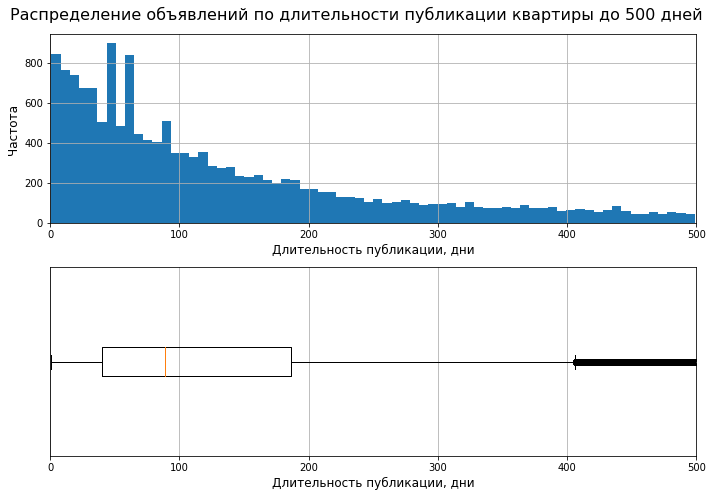

In [90]:
# Построим диаграммы распределения по длительности публикации до 500 дней
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,7))
plt.suptitle('Распределение объявлений по длительности публикации квартиры до 500 дней', size=16)

axes[0].hist(data.query('0 < days_exposition < 500')['days_exposition'], bins = 70)
axes[0].grid()
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Длительность публикации, дни', size=12)
axes[0].set_ylabel('Частота', size=12)

axes[1].boxplot(data.query('0 < days_exposition < 500')['days_exposition'], vert=False)
axes[1].grid()
#axes[1].tick_params(labelleft=False, length=0)
axes[1].set_yticks([])
axes[1].set_xlabel('Длительность публикации, дни', size=12)
axes[1].set_xlim(0, 500)
plt.tight_layout()

В распределении заметны пики, 2 явных, возможно 3

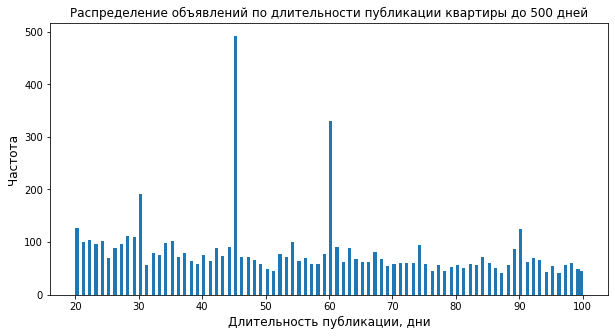

In [91]:
# Построим диаграммы распределения по длительности публикации до 500 дней
data.query('days_exposition < 500')['days_exposition'].plot(kind='hist', \
                                                            bins=160, figsize = (10,5), range=(20,100), \
                                                            title = 'Распределение объявлений по длительности публикации квартиры до 500 дней');
plt.xlabel('Длительность публикации, дни', size=12)
plt.ylabel('Частота', size=12);

#### Вывод

**Вывод по данному разделу:** Среднее время продажи - 185 дней, медианное - 102 дня. То есть обычное время продажи - 3 месяца, правдоподобно. Небольшой пик в районе 30 дней, то есть месяц - скорее всего пользователи, которым нужно быстро продать квратиру, но в целом можно считать что продажа квартиры быстрее, чем 1.5 месяца (1 квартиль), хотя стоит сдвинуть до 1 месяца (из-за пика, про который далее) - класс. Очень долгие - все что больше 3 квартиля - 239 дней и больше. Заметно выдающиейся пики на 45 и 60 днях - вероятно повторная модерация / подтверждение пользователем как в день подачи объявления, то есть много объявлений удаляется. Пик на 90 днях - аналогичен пику 30 днях, но причина немного отличается, теперь есть небольшой пул пользователей, которые не хотели продавать слишком быстро и не хотят слишком долго, выбирают из набранных покупателей лучшего.

### Определение факторов, больше всего влияющих на общую (полную) стоимость объекта

#### Стоимость объектов

count    19950.000000
mean         5.886606
std          4.501106
min          0.430000
25%          3.500000
50%          4.650000
75%          6.700000
max         49.900000
Name: last_price_mill, dtype: float64

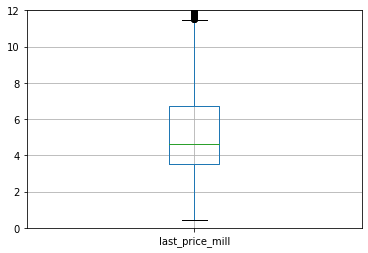

In [92]:
# Оценим параметр стоимость объекта
data.boxplot(column='last_price_mill')
plt.ylim(0, 12)
data['last_price_mill'].describe()

Наблюдаемый максимум 11 млн, дальше выбросы, возьмем при необходимости потолок в 20 млн.

#### Зависимость стоимости объекта от площадей (общей, жилой и кухни)

In [93]:
print('Коэффициент корреляции Пирсона:')
print('Cтоимость-общая площадь -', data['last_price'].corr(data['total_area']).round(3))
print('Cтоимость-жилая площадь -', data['last_price'].corr(data['living_area']).round(3))
print('Cтоимость-площадь кухни -', data['last_price'].corr(data['kitchen_area']).round(3))

Коэффициент корреляции Пирсона:
Cтоимость-общая площадь - 0.769
Cтоимость-жилая площадь - 0.653
Cтоимость-площадь кухни - 0.584


Все положительные и далеки от нуля, больше всего - общая площадь

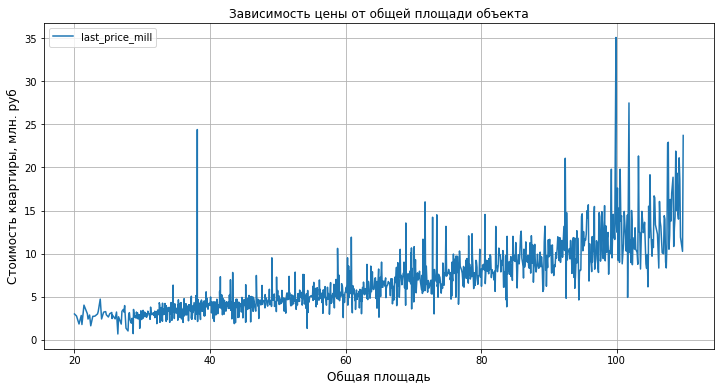

In [94]:
# Построим зависимость цены от общей площади объекта
data.query('(12 < total_area < 110)').pivot_table(index='total_area', values='last_price_mill').plot(grid=True, figsize=(12, 6))
plt.title('Зависимость цены от общей площади объекта')
plt.xlabel('Общая площадь', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

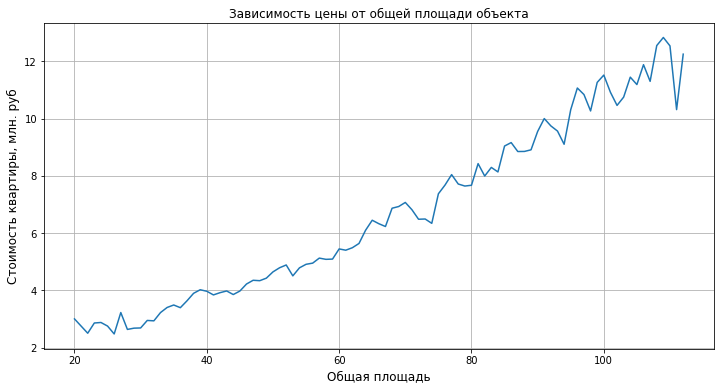

In [95]:
# Ограничим стоимость, чтобы убрать выдающиеся значения и окгрулим площадь до целых чисел от частокола
(
 data.query('(12 < total_area < 112) & (last_price_mill < 20)').round(0).
 pivot_table(index='total_area', values='last_price_mill').
 plot(grid=True, legend=False, figsize=(12, 6))
)
plt.title('Зависимость цены от общей площади объекта')
plt.xlabel('Общая площадь', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

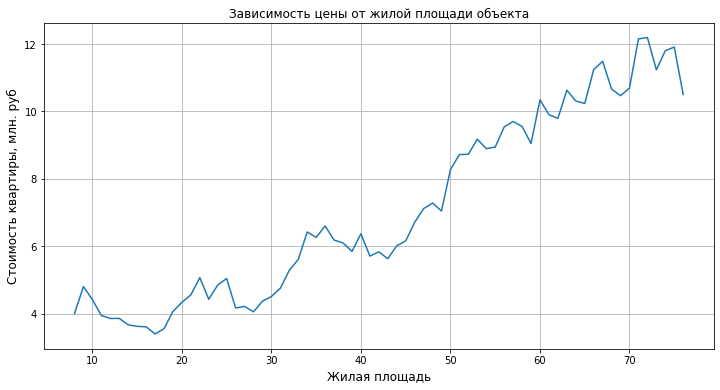

In [96]:
# Аналогично построим зависимость цены от жилой площади объекта
(
 data.query('(8 < living_area < 76) & (last_price_mill < 20)').round().
 pivot_table(index='living_area', values='last_price_mill').
 plot(grid=True, legend=False, figsize=(12, 6))
)
plt.title('Зависимость цены от жилой площади объекта')
plt.xlabel('Жилая площадь', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

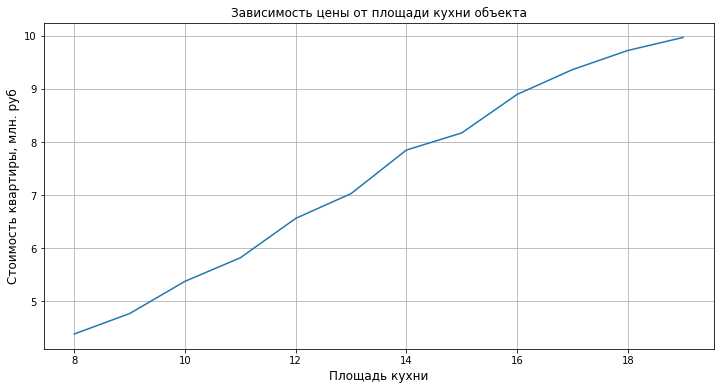

In [97]:
# Аналогично построим зависимость цены от площади кухни объекта
(
 data.query('(8 < kitchen_area < 19) & (last_price_mill < 20)').round().
 pivot_table(index='kitchen_area', values='last_price_mill').
 plot(grid=True, legend=False, figsize=(12, 6))
)
plt.title('Зависимость цены от площади кухни объекта')
plt.xlabel('Площадь кухни', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

In [98]:
print('Коэффициент корреляции Пирсона для графических данных:')
print('Cтоимость-общая площадь -', \
      data.query('(12 < total_area < 112) & (last_price_mill < 20)')['last_price'].corr(data['total_area']).round(3))
print('Cтоимость-жилая площадь -', \
      data.query('(8 < living_area < 76) & (last_price_mill < 20)')['last_price'].corr(data['living_area']).round(3))
print('Cтоимость-площадь кухни -', \
      data.query('(8 < kitchen_area < 19) & (last_price_mill < 20)')['last_price'].corr(data['kitchen_area']).round(3))

Коэффициент корреляции Пирсона для графических данных:
Cтоимость-общая площадь - 0.724
Cтоимость-жилая площадь - 0.6
Cтоимость-площадь кухни - 0.445


Для связок стоимость-общая площадь и стоимость-жилая площадь коэффициент стал больше, для кухни - меньше. Из результатов видна хорошая положительная корреляция между площадями объекта и его стоимостью, что вполне логично, больше всего из них он зависит от общай площадь, что опять же логично - полкупателя впервую очередь интересует она, остальное можно переделать или смириться.

#### Зависимость стоимости объекта от количества комнат

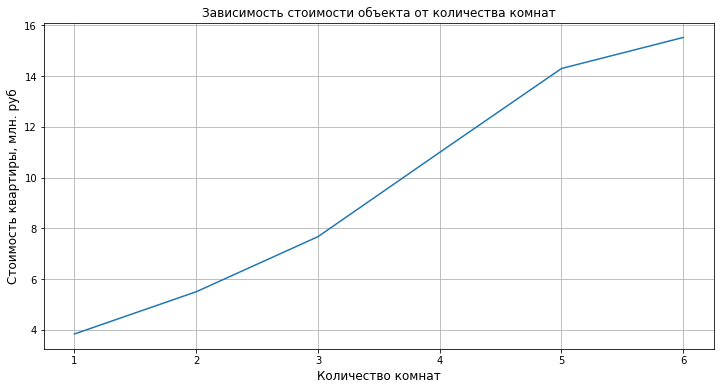

In [99]:
# Построим зависимость стоимости объекта от количества комнат
# Из работы с параметрами нам известно, что выбросы начинались после 6 комнат
data.query('rooms < 7').pivot_table(index='rooms', values='last_price_mill').plot(grid=True, legend=False, figsize=(12, 6));
plt.title('Зависимость стоимости объекта от количества комнат')
plt.xlabel('Количество комнат', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

На 1-комнатные квартиры цена начинается от ~3 млн и заканчивается для 6-комнатной ~36 млн. Уверенный рост цены с увеличением количества комнат.

#### Зависимость стоимости объекта от типа этажа, на котором расположена квартира (первый, последний, другой)

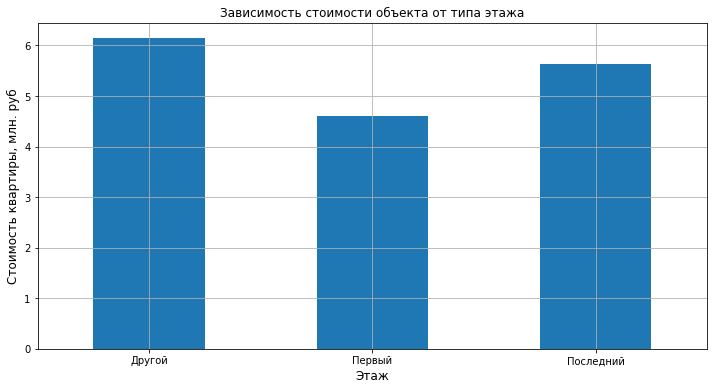

In [100]:
# Построим зависимость стоимости объекта от типа этажа (первый, последний, другой)
(
data.pivot_table(index='floor_category', values='last_price_mill').
    plot(kind ='bar', grid=True, legend=False, figsize=(12, 6), rot=0)
)
plt.title('Зависимость стоимости объекта от типа этажа')
plt.xlabel('Этаж', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

Квартиры на первом этаже стоят дешевле всего. Квартиры между первым и последним этажом дороже всех

#### Зависимость стоимости объекта от даты размещения (день недели, месяц, год)

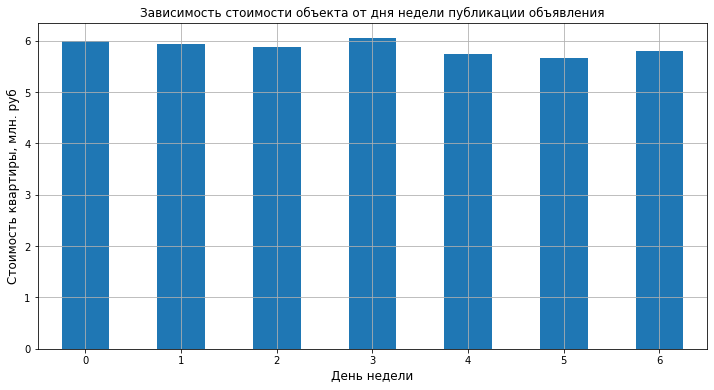

In [101]:
# Построим зависимость стоимости объекта от дня недели публикации объявления
# 0 - понедельник
# 1 - вторник
# 2 - среда
# 3 - четверг
# 4 - пятница
# 5 - суббота
# 6 - воскресенье
(
data.pivot_table(index='weekday_exposition', values='last_price_mill').
plot(kind = 'bar', grid=True, legend=False, figsize=(12, 6), rot=0)
)
plt.title('Зависимость стоимости объекта от дня недели публикации объявления')
plt.xlabel('День недели', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

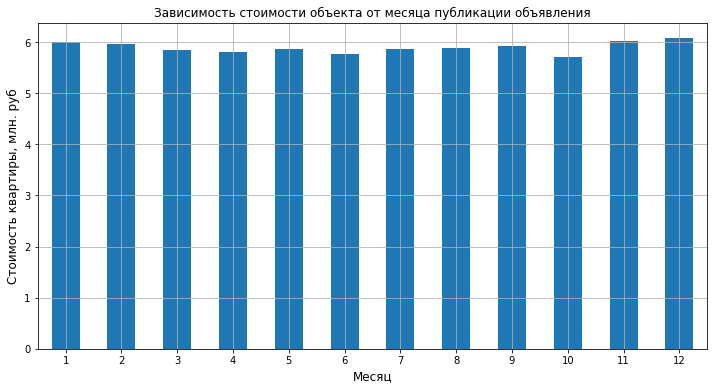

In [102]:
# Построим зависимость стоимости объекта от месяца публикации объявления
(
data.pivot_table(index='month_exposition', values='last_price_mill').
plot(kind = 'bar', grid=True, legend=False, figsize=(12, 6), rot=0)
)
plt.title('Зависимость стоимости объекта от месяца публикации объявления')
plt.xlabel('Месяц', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

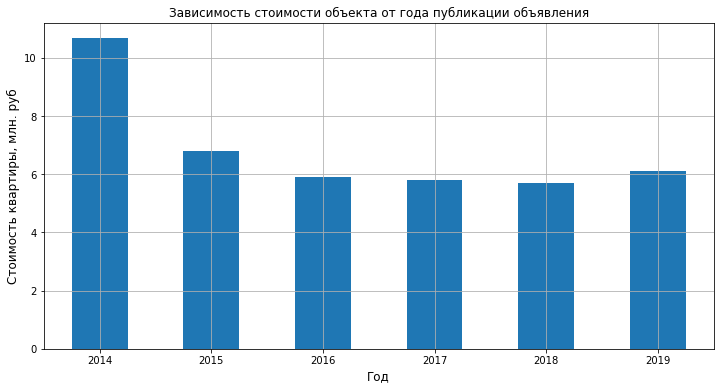

In [103]:
# Построим зависимость стоимости объекта от года публикации объявления
(
data.pivot_table(index='year_exposition', values='last_price_mill').
plot(kind = 'bar', grid=True, legend=False, figsize=(12, 6), rot=0)
)
plt.title('Зависимость стоимости объекта от года публикации объявления')
plt.xlabel('Год', size=12)
plt.ylabel('Стоимость квартиры, млн. руб', size=12);

Зависимости стоимости объекта от дня недели особой нет, хотя незначительно дороже квартиры в субботу. 

С января по март цены немного снижаются, далее подскакивают в апреле и снижаются к лету, где держатся в боковике, снова подскакивают в сентябре - конец сезона отпусков, новая работа, новые идеи после отдыха, как второе начало года, далее резко падают и растут с октября до конца декабря, в новый год в своей квартире!

По годам наблюдается тренд на значимое снижениес 2014 по 2016-2017 год, после чего - относительное плато, в 2014 году доллар вверх, санкции и т.д., для людей - квартира надежная инвестиция и сохранение денег.

#### Вывод

**Вывод по данному разделу:** стоимость явно коррелирует с площадями объекта - общей, жилой и кухни (общей больше всего) с средним коэф.корреляции ~0.6. Также, сильная корреляция с количеством комнат - на 1-комнатные квартиры цена начинается от ~3 млн и заканчивается для 6-комнатной ~36 млн. Дороже всего квартиры между последним и первым этижом. Наблюдаются сезонные колебания - подорожание к весне, к осени и к концу года, в остальные месяцы - снижается. Кроме того, с 2014 года падение цены к 2017 году в ~1.7 раза в связи с экономической ситуацией 2014 года и до 2019 находится на относительном плато.


### Рассчет средней цены 1 кв. метра в 10 населённых пунктах с наибольшим числом объявлений

#### Построим таблицу и графически отобразим статистику

In [104]:
mean_price = (data.
              pivot_table(index='locality_name', values='price_per_meter_thous', aggfunc=['count','mean', 'median'])
              .reset_index()
             )
              
mean_price.columns = ['Поселение','Всего объявлений','Средняя цена за кв.м', 'Медианная цена за кв.м']
mean_price = mean_price.sort_values(by='Всего объявлений', ascending = False, ignore_index=True)
mean_price = mean_price.iloc[:10]
mean_price

,Поселение,Всего объявлений,Средняя цена за кв.м,Медианная цена за кв.м
0,Санкт-Петербург,13261,111.489026,104.170
1,поселок Мурино,428,85.270280,84.925
2,поселок Шушары,380,78.531842,77.355
3,Всеволожск,356,69.102584,65.810
4,Пушкин,321,103.097508,99.740
5,Колпино,318,75.010377,74.565
6,Гатчина,290,68.635793,67.750
7,поселок Парголово,281,90.538897,92.140
8,деревня Кудрово,226,92.248628,91.715
9,Выборг,188,58.441596,58.420


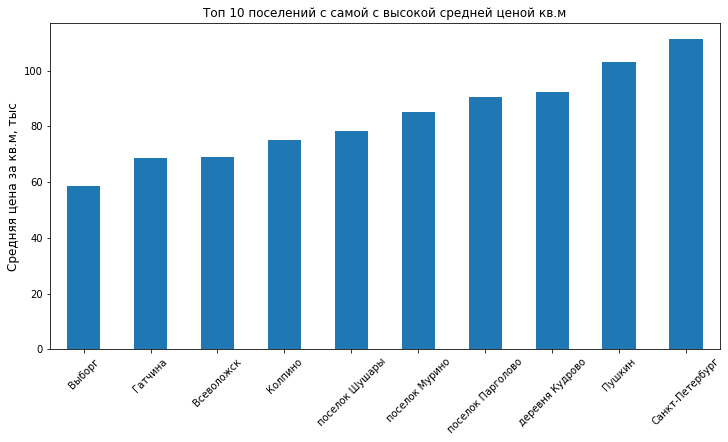

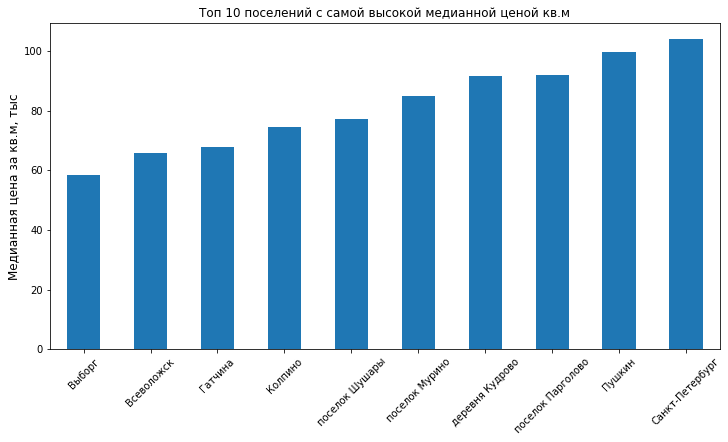

In [105]:
mean_price.sort_values(by='Средняя цена за кв.м').plot(kind='bar', x='Поселение', y='Средняя цена за кв.м', \
                                                       legend= False, figsize=(12,6), rot=45, \
                                                       title='Топ 10 поселений с самой с высокой средней ценой кв.м');
plt.xlabel('')
plt.ylabel('Средняя цена за кв.м, тыс', size=12);
plt.show()

mean_price.sort_values(by='Медианная цена за кв.м').plot(kind='bar', x='Поселение', y='Медианная цена за кв.м', \
                                                       legend= False, figsize=(12,6), rot=45, \
                                                       title='Топ 10 поселений с самой высокой медианной ценой кв.м');
plt.xlabel('')
plt.ylabel('Медианная цена за кв.м, тыс', size=12);

#### Вывод

**Вывод по данному разделу:** самые дорогие объекты в СПб и Пушкине, а дешевые в Выборге. Медианная статистика для стоимости квартир предпочтительнее, потому что стоимость от выбросов мы не фильтровали. Хотя в данном случае разницы практически нет, но Всеволожск и Гатчина места с конца поменялись между собой при переходе на медиану.



- **Топ-3 города по средней стоимости за 1 кв.м.**
     - СПб - 13261 объявления с средней ценой в 111.5 тыс. рублей за кв.м, медианной - 104.2 тыс.
     - Пушкин - 321 объявлений с средней ценой в 103.1 тыс. рублей за кв.м., медианной - 99.7 тыс.
     - деревня Кудрово - 226 объявлений с средней ценой в 92.2 тыс. рублей за кв.м., медианно - 91.7 тыс.
- **3 города с самой дешевой стоимостью 1 кв.м.**
     - Всевлолжск - 356 объявлений с средней ценой в 69.1 тыс. за кв.м., медианной - 65.8 тыс.
     - Гатчина - 290 объявлений с средней ценой в 68.6 тыс. за кв.м., медианной - 67.7 тыс.
     - Выборг - 188 объявлений с средней ценой в 58.4 тыс. за кв.м., медианной - 58.4 тыс.


### Средняя стоимость квартир в Санкт-Петербурге на разном удалении от центра

#### Построим диграммы и составим сводную таблицу по километрам

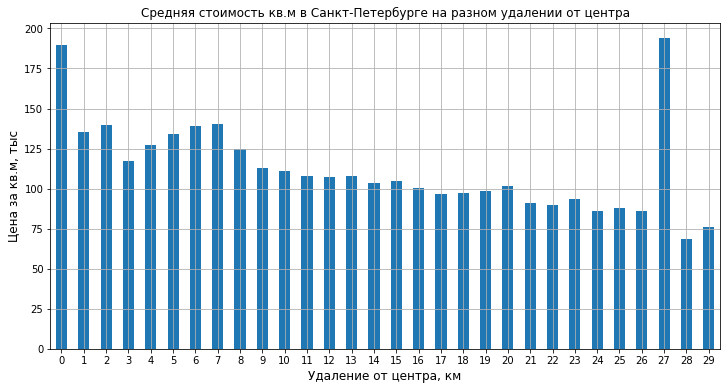

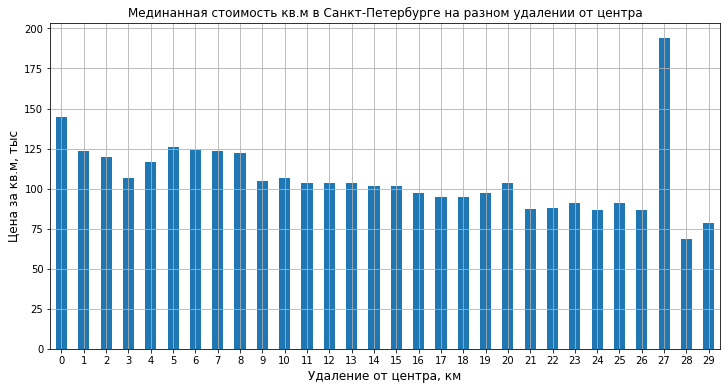

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
"Расстояние до центра, км",0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00,11.00,12.00,13.00,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00,24.00,25.00,26.00,27.00,28.00,29.00
"Средняя цена, млн",189.78,135.65,139.70,117.42,127.29,133.97,139.16,140.32,124.55,112.89,111.25,107.98,107.35,107.62,103.57,104.65,100.23,96.78,97.29,98.75,101.39,90.93,89.97,93.40,85.88,87.97,85.74,193.92,68.47,76.15
"Медианная цена, млн",144.96,123.56,119.88,106.84,116.41,126.23,124.39,123.58,122.52,105.02,106.32,103.55,103.80,103.70,101.37,101.61,97.12,94.81,95.00,96.99,103.70,87.53,87.94,90.91,86.60,90.99,86.40,193.92,68.47,78.23


In [106]:
mean_price_per_km_spb = (data.query('locality_name == "Санкт-Петербург"')
                         .pivot_table(index='cityCenters_nearest_km', values='price_per_meter_thous', aggfunc=['mean','median'])
                         .reset_index().round(2)
                        )
mean_price_per_km_spb.columns = ['Расстояние до центра, км', 'Средняя цена, млн', 'Медианная цена, млн']
mean_price_per_km_spb['Расстояние до центра, км'] = mean_price_per_km_spb['Расстояние до центра, км'].round().astype(int)

mean_price_per_km_spb.plot(kind='bar', x='Расстояние до центра, км', y='Средняя цена, млн', \
                           grid=True, rot=0, legend=False, figsize=(12, 6))
plt.title('Средняя стоимость кв.м в Санкт-Петербурге на разном удалении от центра')
plt.xlabel('Удаление от центра, км', size=12)
plt.ylabel('Цена за кв.м, тыс', size=12)
plt.show()

mean_price_per_km_spb.plot(kind='bar', x='Расстояние до центра, км', y='Медианная цена, млн', \
                           grid=True, rot=0, legend=False, figsize=(12, 6))
plt.title('Мединанная стоимость кв.м в Санкт-Петербурге на разном удалении от центра')
plt.xlabel('Удаление от центра, км', size=12)
plt.ylabel('Цена за кв.м, тыс', size=12)
plt.show()

mean_price_per_km_spb.T

#### Вывод

**Вывод по данному разделу:** самый дорогой средний кв. м в пределах 8 км: от 190 тыс. в пределах 1 км до 140 тыс к 7 км, с минимумом в районе 3 км от центра, где кв.м падает до 117 тыс., вероятно маленькая площадь, убитая отделка или другие невыгодные условия. Далее медленно снижается до 18 км до 97 тыс. за кв.м с небольшим локальным максимумом на 19-20 км - 101 тыс. Возможно новый район с хорошим расположением. Затем снова медленно снижается с заметным локальным максимумом на 27 км - скорее всего небольшой город внутри аггломерации, скорее всего Кронштадт, так как административно в черте города находится.


## Вывод

- **Предобработка данных:**
    - всего обработано 23699 записей данных о продаже квартир в сервисе Яндекс.Недвижимость, осталось 19950 записей
    - 8394 пропуска в высоте потолков заменены медианными значениями в ближайших домах в пределах 100 метров по связке расстояний до аэропорта и центрп города
    - 86 пропусков в количестве этажей заменены выброшены
    - 20924 пропуска в параметре апартаменты заполнены значением False, так как пользователи могут не понимат разницу квартиры и апартаментов
    - 11519 пропусков в балконах заполнены 0, так как пользователи могли не указывать 0 при отсутствии балконв
    - 49 пропусков в названии поселений заполнены названиями из похожих объявлений по расстояниям до центра города и аэропорта, 31 из них выброшены
    - 5542 пропуска в расстоянии до аэропорта заполнены из геоданных Яндекса, осталось меньше 80 пропусков - выброшены
    - 5519 пропусков в расстоянии до центра города заполнены из геоданных Яндекса, осталось меньше 80 пропусков - выброшены
    - 5518 пропусков в расстоянии до ближайшего парка заполнены 0, так как в радиусе 3 км их не было, а данные собирались автоматически
    - 5518 пропусков в расстоянии до ближайшего пруда заполнены 0, так как в радиусе 3 км их не было, а данные собирались автоматически
    - 3181 пропуск в днях экспозиции объявлений заменен 0, так как они существовали меньше 1 дня и, вероятно, не прошли автоматическую проверку пользователя или премодерацию
    - где было необходимо был исправлен тип данных, например, столбец с датой публикации переведен в формат datetime
    - около 3.5 тыс аномалий выброшено из различных параметров
    
    
- **Медианное описание объявления о продаже квартиры:**
    - стоимость - 4.65 млн.рублей
    - 1 или 2 комнаты
    - высота потолка 2.65 м
    - общая площадь - 52 кв.м
    - жилая площадь - 17 или 32 кв.м в зависимости от количества комнат
    - площадь кухни - 6 или 9 кв.м
    - расположена в 5- или 9-этажном доме
    - этаж между первым и последним
    - до центра СПб 14.4 км
    - ближайший парк в 450 метрах, при его наличии в ~1/3 объявлений
    
    
- **Проведенные исследования:**
    - **Скорость продажи квартиры:**
        - среднее время продажи - 185 дней, медианное - 102 дня, т.е. 3 месяца
        - продажи можно считать быстрыми, если это занимает около 1 месяца или чуть меньше
        - продажи можно считать необычайно долгими, если они заняли больше 239 дней, т.е. больше 8 месяцев
        - в зависимости были обнаружены выдающиеся пики на 45 и 60 днях после публикации, которые могут быть связаны с повторной проверкой объявления в сервисе, либо пользователь должен подвтердить его актуальность
        - также были обнаружены небольшие пики на 30 и 90 днях, которые могут быть связаны с намерениями продавцов по скорости продажи, 1 месяц - хотят продать быстро, 3 месяца - набирают пул покупателей и выбирают из него лучшего
    - **Определение факторов влиящих на общую стоимость объекта:**
        - обнаружена явная корреляция стоимости с площадями объекта - общей, жилой и кухни (общей больше всего) с средним коэффициентом корреляции ~0.6
        - выявлена явная положительная корреляция стоимости от количества комнат, на 1-комнатные квартиры цена начинается от ~3 млн. рублей и заканчивается для 6-комнатной ~36 млн. рублей
        - квартиры между первым и последним этажом самые дорогие
        - наблюдаются сезонные колебания - с января по март цены немного снижаются, далее подскакивают в апреле и снижаются к лету, где держатся в боковике, снова подскакивают в сентябре - конец сезона отпусков, новая работа, новые идеи, далее резко падают и растут с октября до конца декабряв предверии нового года
        - замечено падение цены с 2014 года к 2017 году в ~1.7 раза, видимо, в связи с экономической ситуацией 2014 года, и после до 2019 стоимость находилась на относительном плато
    - **Исследование средней цены 1 кв. метра в 10 населённых пунктах с наибольшим числом объявлений:**
        - **Топ-3 города по средней стоимости за 1 кв.м.**
            - СПб - 13261 объявления с средней ценой в 111.5 тыс. рублей за кв.м, медианной - 104.2 тыс.
            - Пушкин - 321 объявлений с средней ценой в 103.1 тыс. рублей за кв.м., медианной - 99.7 тыс.
            - деревня Кудрово - 226 объявлений с средней ценой в 92.2 тыс. рублей за кв.м., медианно - 91.7 тыс.
        - **3 города с самой дешевой стоимостью 1 кв.м.**
            - Всевлолжск - 356 объявлений с средней ценой в 69.1 тыс. за кв.м., медианной - 65.8 тыс.
            - Гатчина - 290 объявлений с средней ценой в 68.6 тыс. за кв.м., медианной - 67.7 тыс.
            - Выборг - 188 объявлений с средней ценой в 58.4 тыс. за кв.м., медианной - 58.4 тыс.
    - **Исследование средней стоимости квартир в Санкт-Петербурге на разном удалении от центра:**
        - самый дорогой средний кв.м в пределах 8 км: стартует от 190 тыс. в пределах 1 км до 140 тыс. к 7 км от центра
        - обнаружен минимум в районе 3 км от центра с ценой 117 тыс., вероятно маленькая площадь, убитая отделка или другие невыгодные условия
        - с 7 по 18 км цена медленно снижается до 97 тыс. за 1 кв.м.
        - в районе 19 км небольшой локальный максимум в 101 тыс., вероятно связан с новым районом
        - в районе 27 км от центра заметный локальный максимум в 193 тыс. за кв.м., это Кронштадт, который административно находится в СПб, он самый дорогой район по среднему и особенно по медиане!
        
        
- **Рекомендации заказчику:**
    - возможно, имеет смысл добавить раздел с примером объявления в виде простой инфографики, чтобы пользователям было проще решать какие значения указывать в полях, если возникнут сомнения. Например в виде всплывающего окна при регистрации + подсказки по ходу дела (не всплывающие)
    - имеет смысл улучшить автоматическую сборку координат по названию или ардесу из геоданных
    - имеет смысл поправить автоматическое заполнение для парков и прудов
    - предлагаю рассмотреть вариант установки фильтров по максимальным и минимальным значениям на некоторые параметры, например комнат не может быть 0, потолок не может быть больше 23 метров и т.д.
    - данные из исследования могут пригодиться в настройке системы по борьбе с аномальными или злоумышленными объявлениями, при расширении выборки, можно обучить модель, которая будет автоматически смотреть как соотносится объявление с похожими в некоторых пределах, и при необходимости сигнализировать о его ручной модерации
    - данные собраны хорошо, были трудности в предобратке, но решаемы, единественный неразрешенный параметр  - время экспозиции объявления, к нему в пару было бы неплохо параметр с флагом, объявление было удалено автоматически или пользователем